In [1]:
"""Main script for training and evaluating Financial GAN."""

import os
from pathlib import Path

# Set the working directory to the root of the project
os.chdir(Path('..').resolve())  # Adjust this path as necessary

import torch
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from src.data.data_loading import (
    get_sp500_tickers, download_stock_data
)
from src.data.data_processing import (
    create_sequences,
    normalize_sequences,
    # denormalize_sequences
)
from src.training.trainer import Trainer
from src.evaluation.metrics import FinancialMetrics
from src.visualization.plots import SequenceVisualizer
from config import Config, setup_logging
import torch
import numpy as np
import matplotlib.pyplot as plt
from src.utils.paths import DIRS

import cProfile
import pstats
from pstats import SortKey
import time

import torch
import numpy as np

# Now you can use DIRS throughout your code
print("Project directories:")
for name, path in DIRS.items():
    print(f"- {name}: {path}")

setup_logging()
logger = logging.getLogger(__name__)

import numpy as np
from typing import Dict, Tuple

# sequence_length = 5
sequence_length = 100

config = Config()
# 1. Data Loading and Processing
print("\n=== Loading Data ===")
tickers = get_sp500_tickers(config)

# Setup profiler
profiler = cProfile.Profile()
profiler.enable()

# Time data loading
data_start = time.time()
# tickers = ['AAPL', 'MMM']
stock_data = download_stock_data(tickers, config)
# stock_data = {key: stock_data[key].head(7) for key in tickers}
# print(stock_data)

import numpy as np
import os

import h5py

# Define paths for HDF5 storage
sequences_hdf5_path = "data/sequences.h5"
normalized_hdf5_path = "data/normalized_data.h5"

import numpy as np
import h5py

valid_stocks, sequences, ticker_mapping = create_sequences(stock_data, sequence_length=sequence_length)

INFO:src.utils.paths:Created directory: /Users/lucijagregov/Documents/gan_finance/data
INFO:src.utils.paths:Created directory: /Users/lucijagregov/Documents/gan_finance/results
INFO:src.utils.paths:Created directory: /Users/lucijagregov/Documents/gan_finance/checkpoints
INFO:src.utils.paths:Created directory: /Users/lucijagregov/Documents/gan_finance/results/plots
INFO:src.utils.paths:Created directory: /Users/lucijagregov/Documents/gan_finance/results/models
INFO:src.utils.paths:Created directory: /Users/lucijagregov/Documents/gan_finance/logs
INFO:src.data.data_loading:Loaded data for 495 stocks


Project directories:
- data: /Users/lucijagregov/Documents/gan_finance/data
- results: /Users/lucijagregov/Documents/gan_finance/results
- checkpoints: /Users/lucijagregov/Documents/gan_finance/checkpoints
- plots: /Users/lucijagregov/Documents/gan_finance/results/plots
- models: /Users/lucijagregov/Documents/gan_finance/results/models
- logs: /Users/lucijagregov/Documents/gan_finance/logs

=== Loading Data ===
data/stock_data.pkl
After filtering: 494 valid stocks out of 495 total


Generating sequences: 100%|██████████| 494/494 [00:10<00:00, 45.09it/s]


In [2]:
import importlib
from src.data import data_processing
importlib.reload(data_processing)

from src.data.data_processing import normalize_with_progress, calculate_global_statistics

# feature_info = calculate_global_statistics(sequences, sample_size=100000)
normalized_data, normalization_params, feature_info = normalize_with_progress(sequences, window_size=5000, sample_size=100000)

Starting normalization of shape (64997, 100, 501)
Starting normalization. Input shape: (64997, 100, 501)


Normalizing: 100%|██████████| 13/13 [00:16<00:00,  1.31s/it]

Normalization completed in 49.70 seconds
Memory usage: 12421.99 MB


Input shapes - Original: (64997, 100, 501), Normalized: (64997, 100, 501)


Processing features: 100%|██████████| 5/5 [00:09<00:00,  1.83s/it]


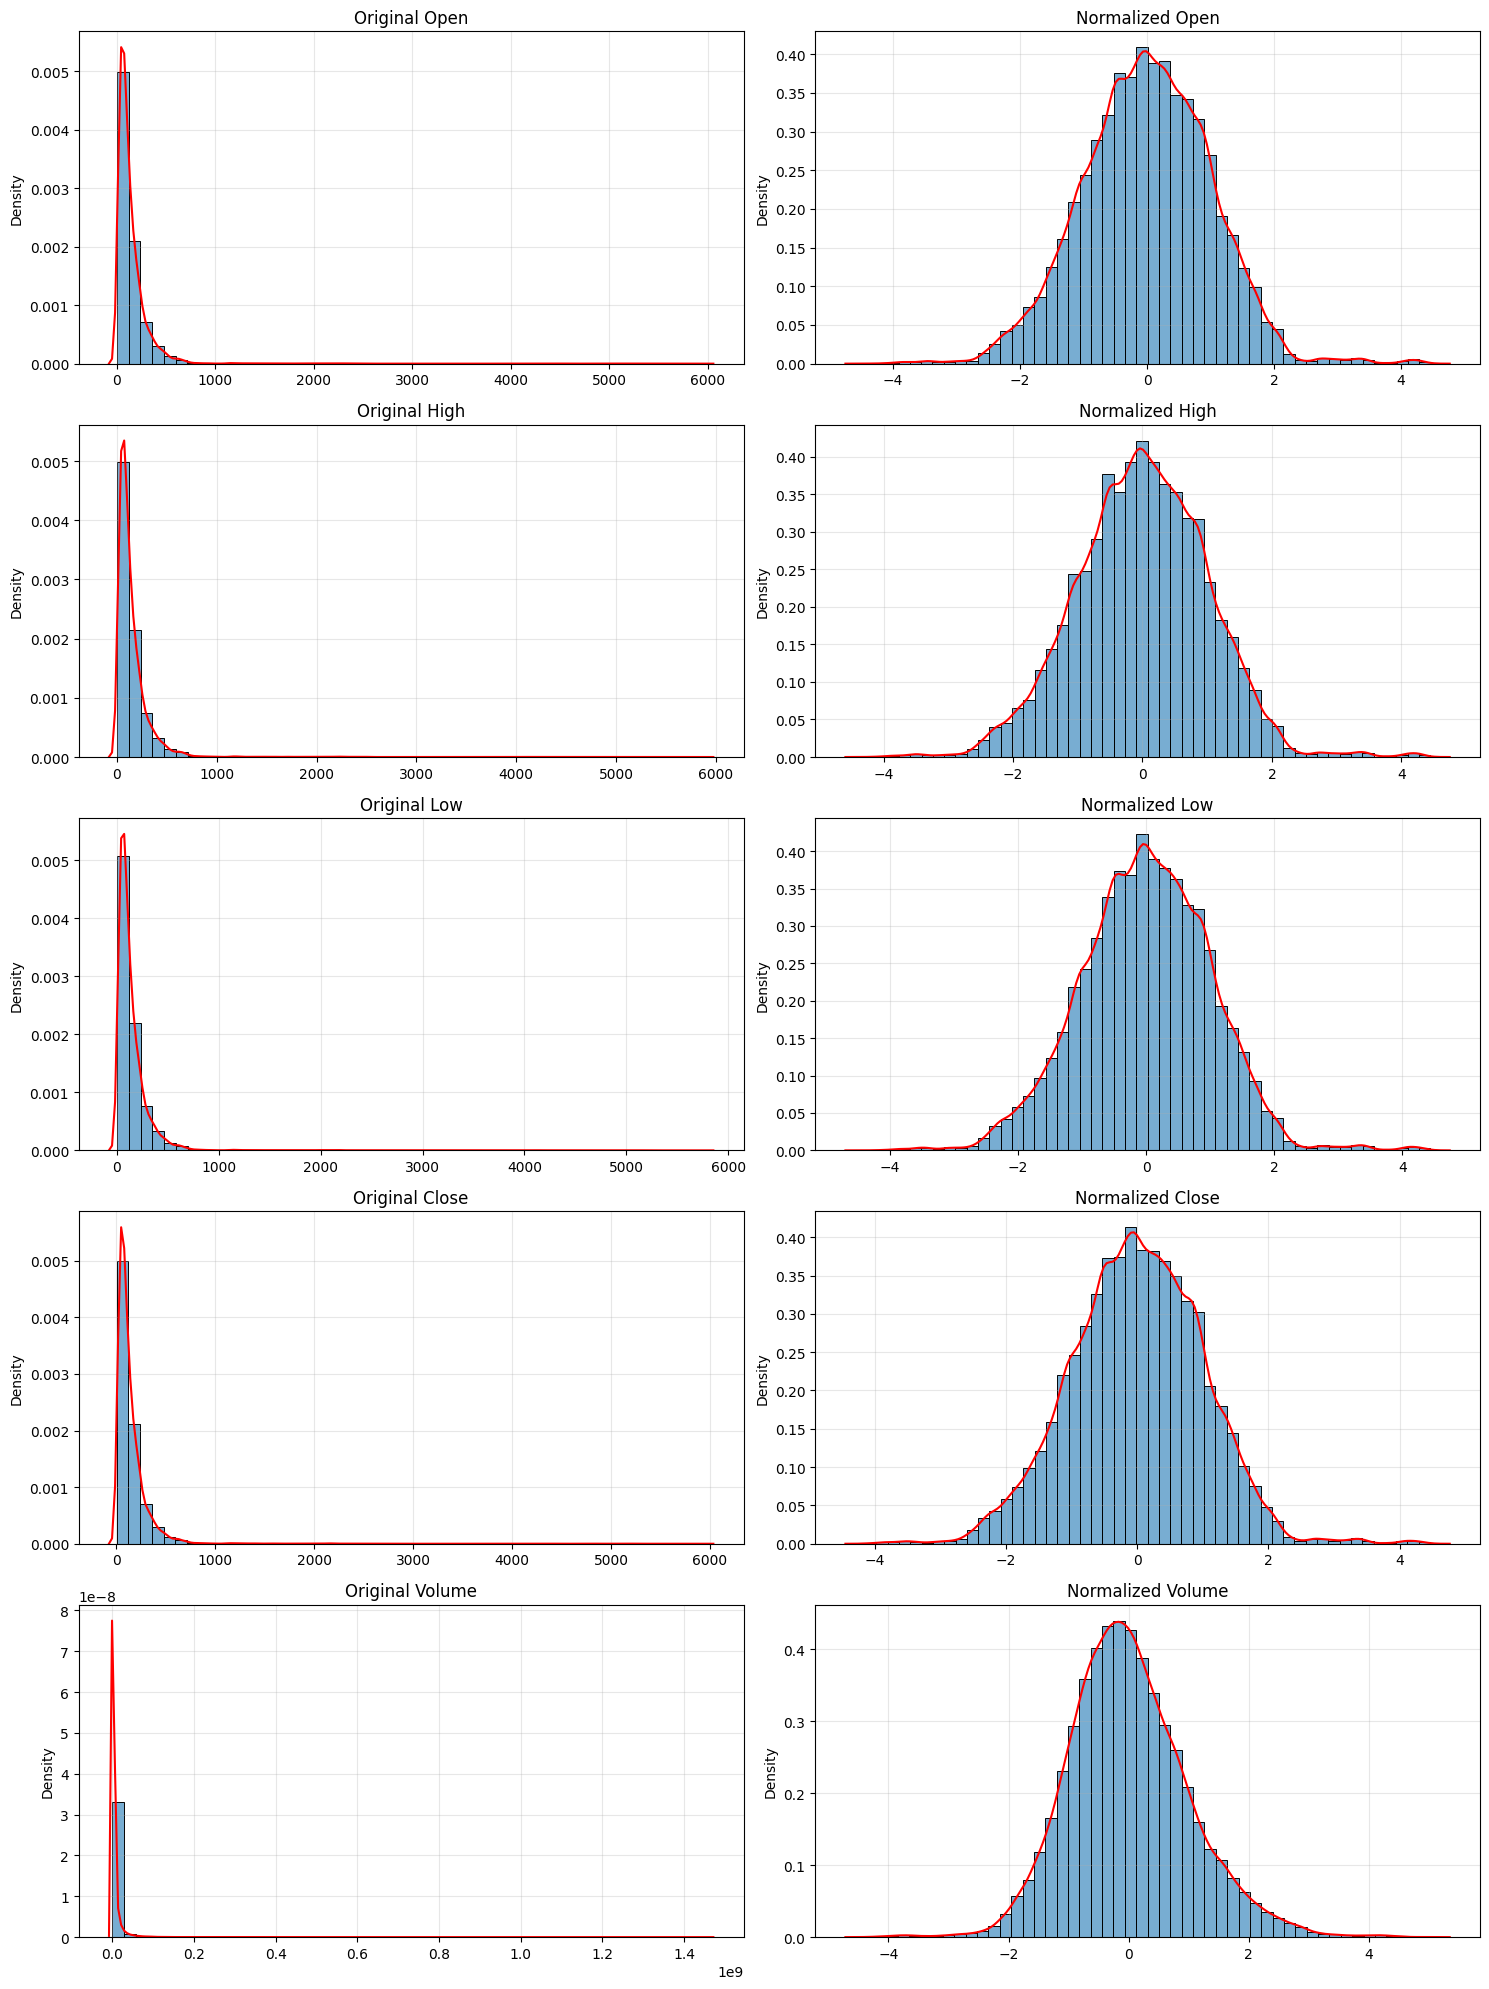


Distribution Statistics Summary:

Open:
----------------------------------------
Original:
  Range: [1.582, 5977.610]
  Mean: 153.441, Std: 265.699
  Percentiles (1%, 99%): [11.170, 729.642]

Normalized:
  Range: [-4.451, 4.467]
  Mean: -0.004, Std: 1.006
  Percentiles (1%, 99%): [-2.335, 2.190]

High:
----------------------------------------
Original:
  Range: [1.881, 5893.500]
  Mean: 156.085, Std: 270.792
  Percentiles (1%, 99%): [11.260, 760.022]

Normalized:
  Range: [-4.286, 4.444]
  Mean: -0.003, Std: 1.009
  Percentiles (1%, 99%): [-2.345, 2.223]

Low:
----------------------------------------
Original:
  Range: [1.633, 5775.980]
  Mean: 151.227, Std: 261.406
  Percentiles (1%, 99%): [10.800, 721.599]

Normalized:
  Range: [-4.392, 4.438]
  Mean: -0.003, Std: 1.006
  Percentiles (1%, 99%): [-2.351, 2.190]

Close:
----------------------------------------
Original:
  Range: [2.098, 5959.330]
  Mean: 152.188, Std: 253.255
  Percentiles (1%, 99%): [11.280, 728.233]

Normalized:
  R

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, Dict
from dataclasses import dataclass
from tqdm import tqdm

@dataclass
class DistributionStats:
    min: float
    max: float
    mean: float
    std: float
    percentiles: Dict[str, float]

def fast_analyze_distributions(
    original_sequences: np.ndarray,
    normalized_sequences: np.ndarray,
    n_features: int = 5,
    batch_size: int = 5000  # Increased batch size
) -> Tuple[Dict[str, DistributionStats], Dict[str, DistributionStats]]:
    """
    High-speed distribution analysis for large sequence datasets.
    """
    print(f"Input shapes - Original: {original_sequences.shape}, Normalized: {normalized_sequences.shape}")
    
    # Pre-flatten the first two dimensions to speed up processing
    orig_flat = original_sequences.reshape(-1, original_sequences.shape[2])
    norm_flat = normalized_sequences.reshape(-1, normalized_sequences.shape[2])
    
    total_samples = len(orig_flat)
    n_features = min(n_features, original_sequences.shape[2])
    
    # Create figure
    fig, axes = plt.subplots(n_features, 2, figsize=(15, 4*n_features))
    if n_features == 1:
        axes = np.array([axes])
    plt.subplots_adjust(hspace=0.4)
    
    # Initialize stats containers
    orig_stats = {}
    norm_stats = {}
    
    feature_names = ['Open', 'High', 'Low', 'Close', 'Volume']
    
    for i in tqdm(range(n_features), desc="Processing features"):
        feature_name = feature_names[i] if i < len(feature_names) else f'Feature_{i}'
        
        # Get random indices for sampling
        sample_indices = np.random.choice(total_samples, size=min(100000, total_samples), replace=False)
        
        # Get samples for current feature
        orig_samples = orig_flat[sample_indices, i]
        norm_samples = norm_flat[sample_indices, i]
        
        # Calculate statistics
        orig_stats[feature_name] = DistributionStats(
            min=np.min(orig_samples),
            max=np.max(orig_samples),
            mean=np.mean(orig_samples),
            std=np.std(orig_samples),
            percentiles={
                '1%': np.percentile(orig_samples, 1),
                '5%': np.percentile(orig_samples, 5),
                '95%': np.percentile(orig_samples, 95),
                '99%': np.percentile(orig_samples, 99)
            }
        )
        
        norm_stats[feature_name] = DistributionStats(
            min=np.min(norm_samples),
            max=np.max(norm_samples),
            mean=np.mean(norm_samples),
            std=np.std(norm_samples),
            percentiles={
                '1%': np.percentile(norm_samples, 1),
                '5%': np.percentile(norm_samples, 5),
                '95%': np.percentile(norm_samples, 95),
                '99%': np.percentile(norm_samples, 99)
            }
        )
        
        # Plot distributions
        sns.histplot(orig_samples, bins=50, ax=axes[i, 0], stat='density', alpha=0.6)
        sns.kdeplot(orig_samples, ax=axes[i, 0], color='red')
        axes[i, 0].set_title(f'Original {feature_name}')
        axes[i, 0].grid(True, alpha=0.3)
        
        sns.histplot(norm_samples, bins=50, ax=axes[i, 1], stat='density', alpha=0.6)
        sns.kdeplot(norm_samples, ax=axes[i, 1], color='red')
        axes[i, 1].set_title(f'Normalized {feature_name}')
        axes[i, 1].grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\nDistribution Statistics Summary:")
    print("=" * 80)
    
    for feature_name in list(orig_stats.keys()):
        print(f"\n{feature_name}:")
        print("-" * 40)
        
        orig = orig_stats[feature_name]
        print("Original:")
        print(f"  Range: [{orig.min:.3f}, {orig.max:.3f}]")
        print(f"  Mean: {orig.mean:.3f}, Std: {orig.std:.3f}")
        print(f"  Percentiles (1%, 99%): [{orig.percentiles['1%']:.3f}, {orig.percentiles['99%']:.3f}]")
        
        norm = norm_stats[feature_name]
        print("\nNormalized:")
        print(f"  Range: [{norm.min:.3f}, {norm.max:.3f}]")
        print(f"  Mean: {norm.mean:.3f}, Std: {norm.std:.3f}")
        print(f"  Percentiles (1%, 99%): [{norm.percentiles['1%']:.3f}, {norm.percentiles['99%']:.3f}]")
    
    return orig_stats, norm_stats

def quick_feature_correlations(
    sequences: np.ndarray,
    n_features: int = 5,
    sample_size: int = 100000
) -> None:
    """Quick correlation analysis using sampling."""
    # Flatten and sample
    flat_data = sequences.reshape(-1, sequences.shape[2])
    if len(flat_data) > sample_size:
        indices = np.random.choice(len(flat_data), sample_size, replace=False)
        flat_data = flat_data[indices]
    
    # Calculate correlations for first n_features
    corr_matrix = np.corrcoef(flat_data[:, :n_features].T)
    
    # Plot
    plt.figure(figsize=(10, 8))
    feature_names = ['Open', 'High', 'Low', 'Close', 'Volume']
    sns.heatmap(corr_matrix,
                annot=True,
                fmt='.2f',
                square=True,
                xticklabels=feature_names[:n_features],
                yticklabels=feature_names[:n_features],
                cmap='RdBu',
                center=0)
    plt.title("Feature Correlations (Sampled Data)")
    plt.tight_layout()
    plt.show()

orig_stats, norm_stats = fast_analyze_distributions(
    original_sequences=sequences,
    normalized_sequences=normalized_data,
    n_features=5  # Analyze first 5 features
)

In [44]:
stock_data['MMM']

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,148.561874,150.510040,148.110367,150.501678,4307633
2020-01-03,148.010040,149.381271,146.847824,149.205688,2950412
2020-01-06,148.118729,149.423080,147.449829,149.347824,2389608
2020-01-07,149.063538,149.255859,147.842804,148.745819,2598908
2020-01-08,148.829437,151.755859,148.536789,151.028427,3298927
...,...,...,...,...,...
2022-12-23,100.994980,101.170570,98.494980,100.451508,3120723
2022-12-27,100.451508,101.028427,99.632111,100.518394,2166195
2022-12-28,100.627090,101.170570,98.871239,98.904678,2345356


In [ ]:
normalized_data.shape

(64997, 100, 501)

Generated Open, High, Low, Close, Volume for first sample in batch:
Epoch [1/2000], D Loss: 0.9728, G Loss: 20.7971, Consistency: 3.4829607010, Volatility: 0.3506966829
len(denorm_real_batch) 32

Denormalized Original Sequence:
[[    148.5619     150.5101     148.1104     150.5017 4307632.5   ]
 [    148.01       149.3813     146.8479     149.2057 2950411.5   ]
 [    148.1187     149.4231     147.4498     149.3478 2389607.8   ]
 [    149.0635     149.2559     147.8428     148.7458 2598908.8   ]
 [    148.8294     151.7559     148.5368     151.0284 3298926.    ]]

Denormalized Generated Sequence:
[[    159.7077     116.6268     107.1356     162.4542 6568549.    ]
 [     91.3025      87.8275      89.8468     168.0601 3647436.8   ]
 [    124.5175      69.6823      92.806      212.0217 1027906.44  ]
 [     94.819       61.7453      65.2831      93.0454 1592553.8   ]
 [     85.5087      82.0798      56.8678     163.1393 5194946.    ]]

Percentage (Generated - Original):
[[   6.9789  -29.052

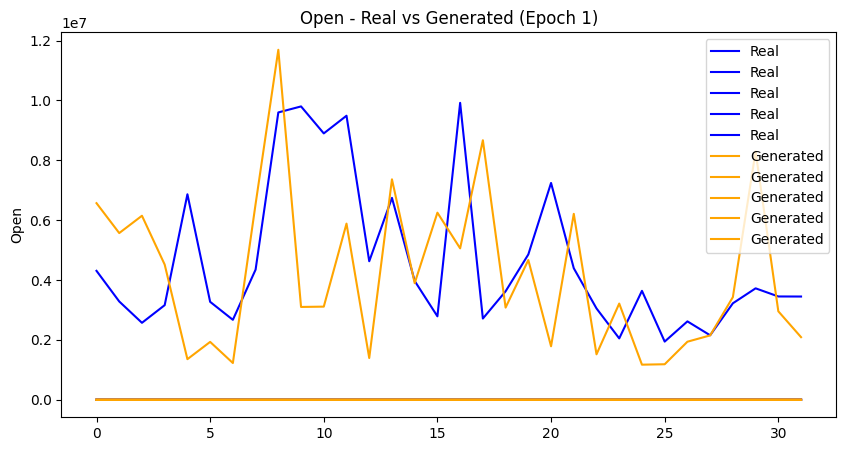

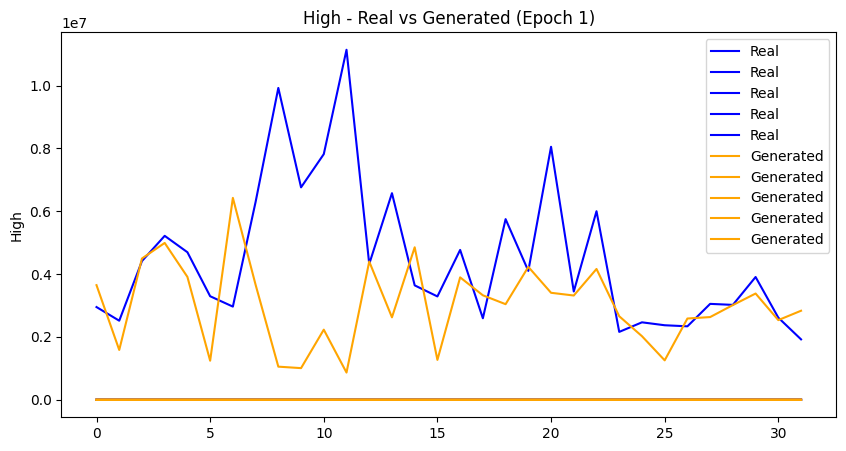

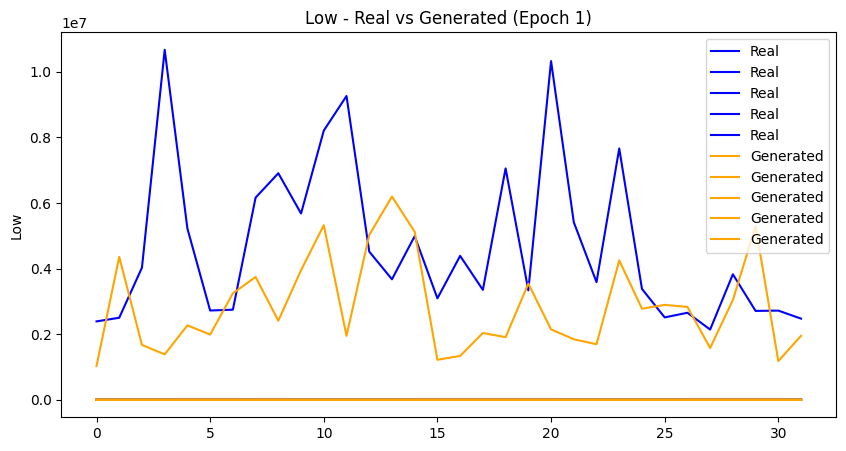

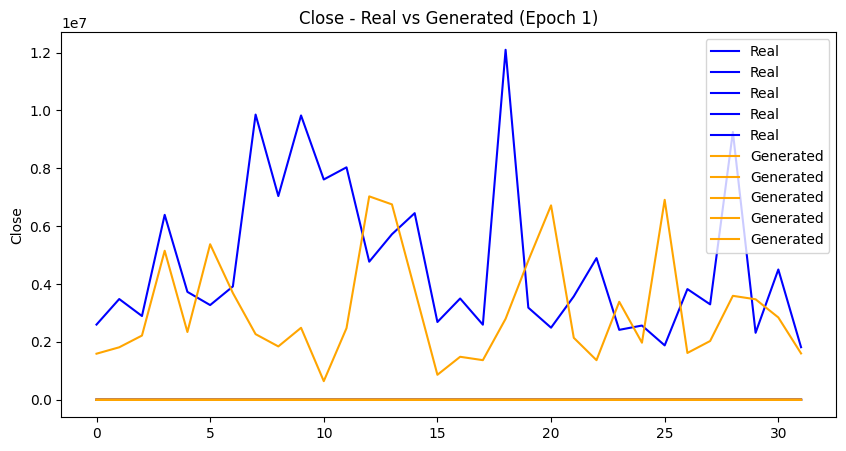

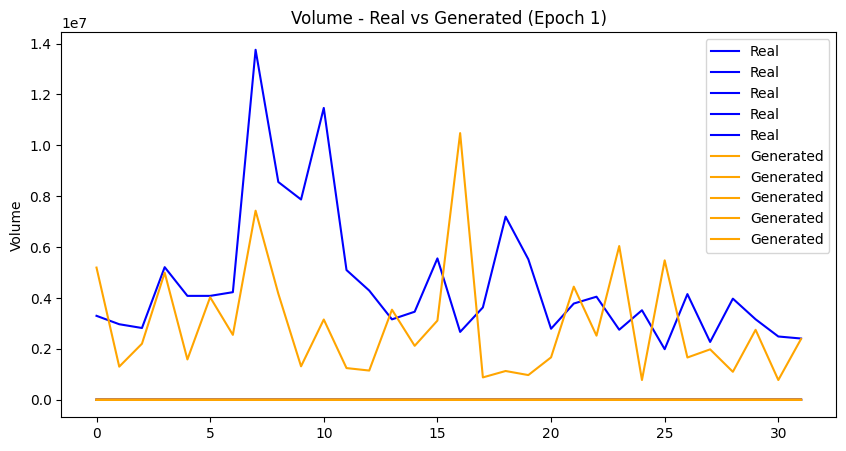

/Users/lucijagregov/Documents/gan_finance/.venv_finance/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/Users/lucijagregov/Documents/gan_finance/.venv_finance/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


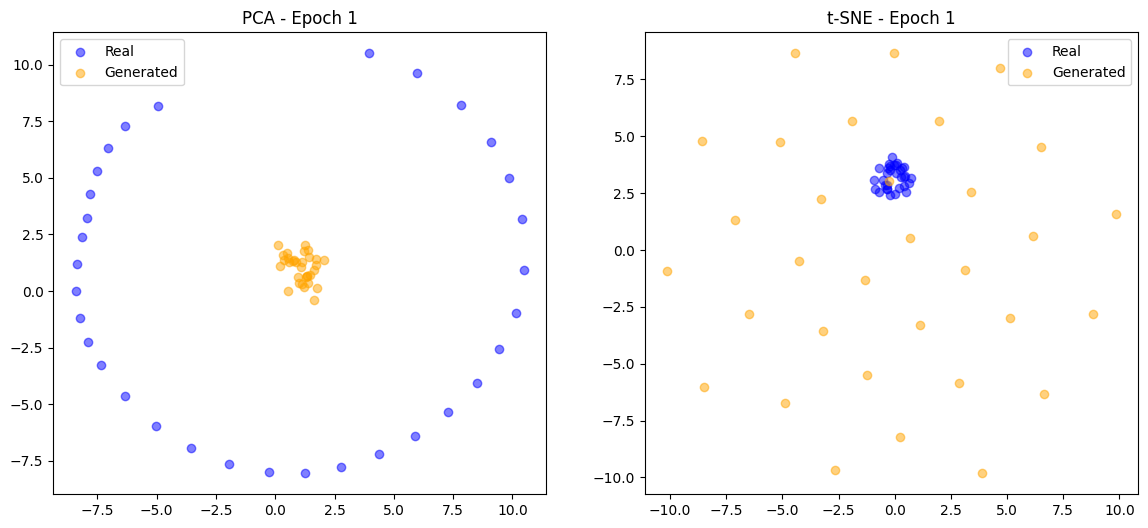

Generated Open, High, Low, Close, Volume for first sample in batch:
Epoch [3/2000], D Loss: 0.9733, G Loss: 19.6911, Consistency: 3.1976428032, Volatility: 0.3490417302
len(denorm_real_batch) 32

Denormalized Original Sequence:
[[    165.719      166.6304     164.7659     165.4097 2011792.9   ]
 [    163.888      164.9917     163.3528     164.2726 2702600.    ]
 [    163.5033     165.0418     163.0602     164.5067 1883700.2   ]
 [    164.9498     165.393      163.8044     165.1171 1748074.2   ]
 [    166.1538     166.9482     165.5351     166.0368 3312321.2   ]]

Denormalized Generated Sequence:
[[     82.0875     175.7829      49.7386      94.2853 2233822.    ]
 [     86.2574     143.8083      89.6044     102.6673 3236298.    ]
 [     94.7935     217.4464      96.3172     103.9367 1582401.2   ]
 [     72.384      123.9099      52.9193      69.9646 3400812.5   ]
 [    124.8008     144.81        64.948      114.3853 1745354.    ]]

Percentage (Generated - Original):
[[-101.881     5.206

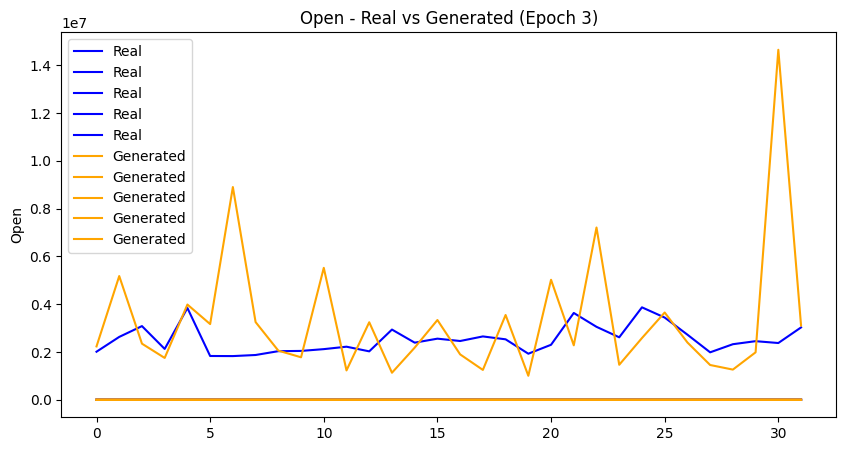

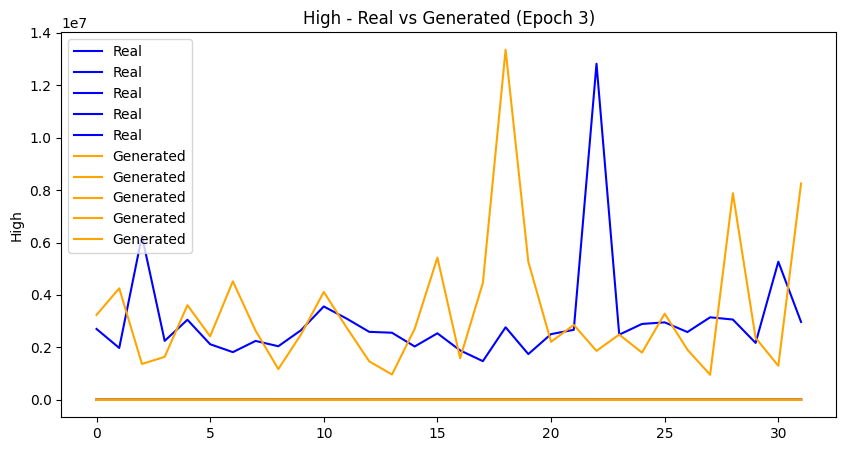

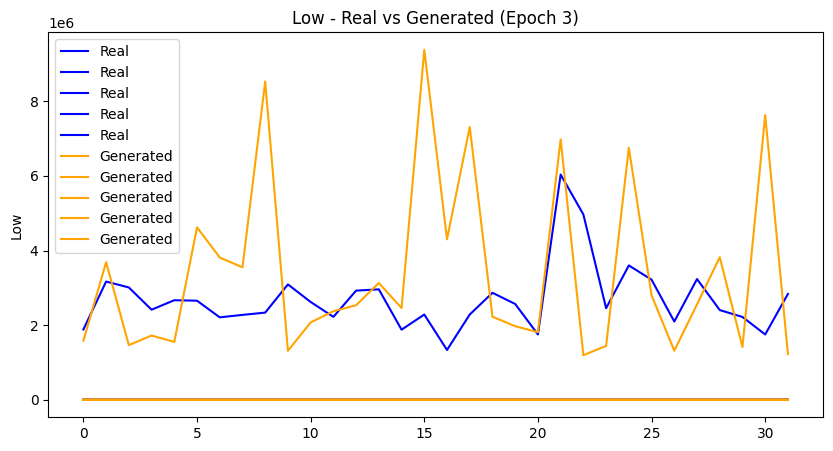

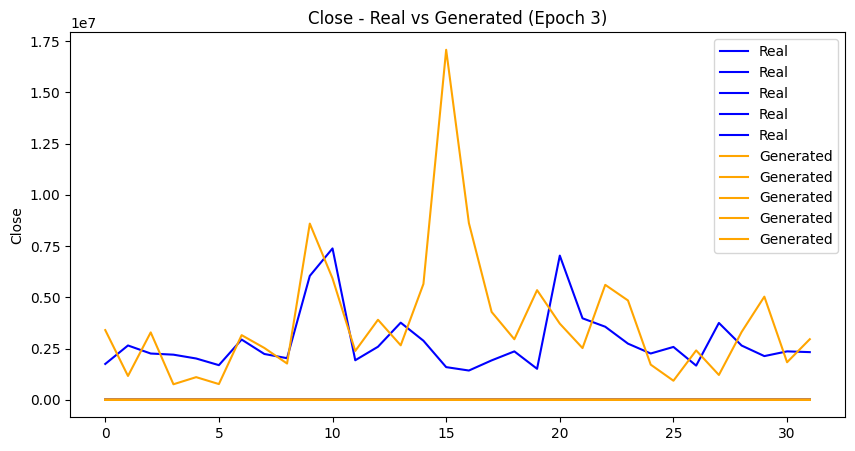

KeyboardInterrupt: 

In [80]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from src.data.data_processing import denormalize
np.set_printoptions(suppress=True, precision=4)

# ====================== Generator Class ======================

class TransformerGenerator(nn.Module):
    """
    Transformer-based generator for financial time series data.
    
    Args:
        noise_dim (int): Dimension of the input noise vector
        feature_dim (int): Dimension of the output features
        transformer_dim (int): Dimension of the transformer's hidden states
        n_heads (int): Number of attention heads
        n_layers (int): Number of transformer layers
    """
    def __init__(self, noise_dim: int, feature_dim: int, transformer_dim: int, 
                 n_heads: int, n_layers: int):
        super(TransformerGenerator, self).__init__()
        self.input_layer = nn.Linear(noise_dim + feature_dim + 2, transformer_dim)  # Removed ticker_dim
        self.transformer = nn.Transformer(
            d_model=transformer_dim, nhead=n_heads, num_encoder_layers=n_layers,
            num_decoder_layers=n_layers, dim_feedforward=128, batch_first=True
        )
        self.output_layer = nn.Linear(transformer_dim, feature_dim)

    def forward(self, noise: torch.Tensor, day_encoding: torch.Tensor, 
                historical_data_summary: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the generator.
        
        Args:
            noise (torch.Tensor): Random noise input [batch_size, sequence_length, noise_dim]
            day_encoding (torch.Tensor): Day encoding [batch_size, sequence_length, 2]
            historical_data_summary (torch.Tensor): Historical data summary [batch_size, sequence_length, feature_dim]
            
        Returns:
            torch.Tensor: Generated sequences [batch_size, sequence_length, feature_dim]
        """
        x = torch.cat([historical_data_summary, noise, day_encoding], dim=2)  # Removed ticker_embedding
        x = self.input_layer(x)
        x = self.transformer(x, x)
        return self.output_layer(x)




# ====================== Discriminator Class ======================

class LSTMDiscriminator(nn.Module):
    """
    Discriminator model using an LSTM architecture.

    Args:
        feature_dim (int): Dimensionality of the feature space.
        hidden_dim1_disc (int): Dimensionality of the first hidden layer.
        hidden_dim2_disc (int): Dimensionality of the second hidden layer.
    """
    def __init__(self, feature_dim: int, hidden_dim1_disc: int, hidden_dim2_disc: int):
        super(LSTMDiscriminator, self).__init__()
        self.fc1 = nn.Linear(feature_dim, hidden_dim1_disc)
        self.lstm = nn.LSTM(input_size=hidden_dim1_disc, hidden_size=hidden_dim2_disc, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim2_disc, 1)

    def forward(self, x: torch.Tensor, add_noise: bool = True) -> torch.Tensor:
        if add_noise:
            x = x + torch.randn_like(x) * 0.05
        x = F.leaky_relu(self.fc1(x))
        lstm_out, (h_n, _) = self.lstm(x)
        features = h_n.squeeze(0)
        output = torch.sigmoid(self.fc_out(features))
        return output, features

# ====================== Helper Functions ======================

def compare_gen_orig(epoch_to_compare, stored_real_sequences, stored_generated_sequences):
    # Cell 1: Let's look at the generated sequences for the first stored epoch
    # epoch_to_compare = 0  # Change this to the index of the epoch you want to compare

    # Assuming stored sequences are not empty
    if stored_real_sequences and stored_generated_sequences:
        # print('stored_real_sequences[epoch_to_compare]', stored_real_sequences)
        original_seq = stored_real_sequences[epoch_to_compare][0]  # First sequence
        generated_seq = stored_generated_sequences[epoch_to_compare][0]  # First generated sequence

        # print("Original sequence (Epoch {}):".format(epoch_to_compare + 1))
        # print(original_seq)

        # print("\nGenerated sequence (Epoch {}):".format(epoch_to_compare + 1))
        # print(generated_seq)

    # Cell 2: Denormalize both sequences for comparison
    denorm_original = denormalize(original_seq, feature_info)
    denorm_generated = denormalize(generated_seq, feature_info)

    print("\nDenormalized Original Sequence:")
    print(denorm_original[:5])

    print("\nDenormalized Generated Sequence:")
    print(denorm_generated[:5])

    # Cell 3: Compare Denormalized Sequences
    # print("\nDifference (Generated - Original):")
    # print(denorm_generated - denorm_original)
    perc_diff = (denorm_generated - denorm_original) / (denorm_generated / 100)
    print("\nPercentage (Generated - Original):")

    print(perc_diff[:5])


def summarize_historical_data(historical_data: torch.Tensor, window: int) -> torch.Tensor:
    """
    Summarize the last few periods of historical data.

    Args:
        historical_data (torch.Tensor): Input historical data.
        window (int): Number of periods to average over.

    Returns:
        torch.Tensor: Summarized historical data.
    """
    return historical_data[:, -window:, :].mean(dim=1).unsqueeze(1).expand(-1, sequence_length, -1)

def generate_day_encoding(sequence_length: int, batch_size: int) -> torch.Tensor:
    """
    Generate cyclical day encoding for sequences.

    Args:
        sequence_length (int): Length of the sequence.
        batch_size (int): Size of each batch.

    Returns:
        torch.Tensor: Day encoding for each day in the sequence.
    """
    days = np.arange(sequence_length) % 7
    days_rad = days * (2 * np.pi / 7)
    sin_day = np.sin(days_rad)
    cos_day = np.cos(days_rad)
    sin_day_batch = np.tile(sin_day, (batch_size, 1)).reshape(batch_size, sequence_length, 1)
    cos_day_batch = np.tile(cos_day, (batch_size, 1)).reshape(batch_size, sequence_length, 1)
    day_encoding = np.concatenate([sin_day_batch, cos_day_batch], axis=2)
    return torch.tensor(day_encoding, dtype=torch.float32)

def gradient_penalty(disc_func, real_data: torch.Tensor, fake_data: torch.Tensor) -> torch.Tensor:
    """
    Calculate gradient penalty for WGAN-GP.

    Args:
        disc_func (nn.Module): Discriminator function.
        real_data (torch.Tensor): Real sequences.
        fake_data (torch.Tensor): Fake sequences.

    Returns:
        torch.Tensor: Gradient penalty term.
    """
    batch_size, seq_len, feature_dim = real_data.shape
    # print(f"Real data shape: {real_data.shape}")
    # print(f"Fake data shape: {fake_data.shape}")
    
    # Make sure real_data and fake_data are aligned in dimensions
    assert real_data.shape == fake_data.shape, "Shape mismatch between real and generated sequences"

    alpha = torch.rand(batch_size, seq_len, feature_dim, requires_grad=True).to(real_data.device)
    interpolated = (alpha * real_data + (1 - alpha) * fake_data).requires_grad_(True)
    disc_interpolates, _ = disc_func(interpolated)
    gradients = torch.autograd.grad(
        outputs=disc_interpolates, inputs=interpolated,
        grad_outputs=torch.ones_like(disc_interpolates),
        create_graph=True, retain_graph=True
    )[0]
    gradients = gradients.view(gradients.size(0), -1)
    gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean() * lambda_gp
    return gp


def volatility_loss(real_sequences: torch.Tensor, generated_sequences: torch.Tensor, epoch: int, base_smoothing: float = 5e-4) -> torch.Tensor:
    """
    Volatility matching loss between real and generated sequences.

    Args:
        real_sequences (torch.Tensor): Real sequences.
        generated_sequences (torch.Tensor): Generated sequences.
        epoch (int): Current training epoch.
        base_smoothing (float): Smoothing factor for loss.

    Returns:
        torch.Tensor: Volatility loss.
    """
    smoothing_factor = base_smoothing if epoch < 1500 else base_smoothing / 10
    real_returns = torch.diff(real_sequences[..., 3], dim=1)
    gen_returns = torch.diff(generated_sequences[..., 3], dim=1)
    mean_volatility_loss = F.mse_loss(gen_returns.mean(dim=1), real_returns.mean(dim=1))
    variance_volatility_loss = F.mse_loss(gen_returns.std(dim=1), real_returns.std(dim=1))
    return mean_volatility_loss + variance_volatility_loss + smoothing_factor

def diversity_loss(generated_sequences: torch.Tensor) -> torch.Tensor:
    """
    Diversity loss to encourage variance in generated sequences.

    Args:
        generated_sequences (torch.Tensor): Generated sequences.

    Returns:
        torch.Tensor: Diversity loss.
    """
    sequence_var = torch.var(generated_sequences, dim=1)
    return torch.mean(1.0 / (sequence_var + 1e-6))

def price_consistency_loss(sequences: torch.Tensor) -> torch.Tensor:
    """
    Enforce consistency in price sequences.

    Args:
        sequences (torch.Tensor): Price sequences.

    Returns:
        torch.Tensor: Price consistency loss.
    """
    open_price = sequences[..., 0]
    high = sequences[..., 1]
    low = sequences[..., 2]
    high_open_violation = F.relu(open_price - high + 1e-2) ** 2
    open_low_violation = F.relu(low - open_price + 1e-2) ** 2
    return torch.mean(10 * high_open_violation + 10 * open_low_violation)

def temporal_consistency_loss(sequences: torch.Tensor) -> torch.Tensor:
    """
    Enforce temporal consistency by reducing large changes in prices.

    Args:
        sequences (torch.Tensor): Price sequences.

    Returns:
        torch.Tensor: Temporal consistency loss.
    """
    close_prices = sequences[..., 3]
    return torch.mean(torch.abs(torch.diff(close_prices, dim=1)))

def generate_samples(num_samples, ticker_idx):
    """Generate samples for a specific ticker."""
    matching_sequences = []
    ticker_start = ohlcv_dim
    
    for i in range(len(normalized_data)):
        if np.argmax(normalized_data[i, 0, ticker_start:ticker_start + ticker_dim]) == ticker_idx:
            matching_sequences.append(normalized_data[i])
            if len(matching_sequences) >= num_samples:
                break

    if len(matching_sequences) < num_samples:
        print(f"Insufficient matching sequences found for ticker index {ticker_idx}. Needed: {num_samples}, Found: {len(matching_sequences)}")
        return None, None  # Return None if not enough sequences found

    real_sequences = torch.tensor(np.array(matching_sequences), dtype=torch.float32)
    day_encoding = generate_day_encoding(sequence_length, len(matching_sequences))

    # Get the ticker embedding for generation
    ticker_embedding = generator.ticker_embedding_layer(torch.tensor([ticker_idx] * len(matching_sequences), dtype=torch.long)).to(real_sequences.device)
    ticker_embedding = ticker_embedding.unsqueeze(1).expand(-1, sequence_length, -1)

    with torch.no_grad():
        noise = torch.randn(len(matching_sequences), sequence_length, noise_dim).to(real_sequences.device)
        generated = generator(noise, day_encoding, summarize_historical_data(real_sequences, sequence_length), ticker_embedding)

    return generated.numpy(), np.array(matching_sequences)


def generate_sequences_for_stock(real_features):
    """
    Generate synthetic sequences for a specific stock using the Transformer generator.

    Args:
        real_features (torch.Tensor): The real feature data of shape [batch_size, sequence_length, feature_dim].

    Returns:
        torch.Tensor: Generated sequences of shape [batch_size, sequence_length, feature_dim].
    """
    batch_size = real_features.shape[0]
    noise = torch.randn(batch_size, sequence_length, noise_dim)
    day_encoding = generate_day_encoding(sequence_length, batch_size)
    ticker_embedding = ticker_embedding_layer(torch.tensor([ticker_idx] * batch_size).to(real_features.device))
    ticker_embedding = ticker_embedding.unsqueeze(1).expand(-1, sequence_length, -1)  # Adjust shape

    generated_sequence = generator(noise, day_encoding, summarize_historical_data(real_features, sequence_length), ticker_embedding)
    return generated_sequence

def compare_statistics(real, generated, ticker):
    """Compare statistics between real and generated samples, with percentage error"""
    print(f"\nStatistics for {ticker}:")

    # OHLC statistics
    print("\nOHLC Statistics:")
    for i, name in enumerate(['Open', 'High', 'Low', 'Close']):
        real_mean = real[..., i].mean()
        real_std = real[..., i].std()
        gen_mean = generated[..., i].mean()
        gen_std = generated[..., i].std()
        
        mean_error = abs((gen_mean - real_mean) / real_mean) * 100 if real_mean != 0 else float('inf')
        std_error = abs((gen_std - real_std) / real_std) * 100 if real_std != 0 else float('inf')
        
        print(f"\n{name}:")
        print(f"Real - Mean: {real_mean:.4f}, Std: {real_std:.4f}")
        print(f"Generated - Mean: {gen_mean:.4f}, Std: {gen_std:.4f}")
        print(f"Mean Error: {mean_error:.2f}%, Std Error: {std_error:.2f}%")

    # Volume statistics
    real_volume_mean = real[..., 4].mean()
    real_volume_std = real[..., 4].std()
    gen_volume_mean = generated[..., 4].mean()
    gen_volume_std = generated[..., 4].std()
    
    volume_mean_error = abs((gen_volume_mean - real_volume_mean) / real_volume_mean) * 100 if real_volume_mean != 0 else float('inf')
    volume_std_error = abs((gen_volume_std - real_volume_std) / real_volume_std) * 100 if real_volume_std != 0 else float('inf')

    print("\nVolume Statistics:")
    print(f"Real - Mean: {real_volume_mean:.4f}, Std: {real_volume_std:.4f}")
    print(f"Generated - Mean: {gen_volume_mean:.4f}, Std: {gen_volume_std:.4f}")
    print(f"Mean Error: {volume_mean_error:.2f}%, Std Error: {volume_std_error:.2f}%")

    # Daily Returns Statistics
    real_returns = np.diff(real[..., 3], axis=1)
    gen_returns = np.diff(generated[..., 3], axis=1)
    
    real_return_mean = real_returns.mean()
    real_return_std = real_returns.std()
    gen_return_mean = gen_returns.mean()
    gen_return_std = gen_returns.std()
    
    return_mean_error = abs((gen_return_mean - real_return_mean) / real_return_mean) * 100 if real_return_mean != 0 else float('inf')
    return_std_error = abs((gen_return_std - real_return_std) / real_return_std) * 100 if real_return_std != 0 else float('inf')
    
    print("\nDaily Returns Statistics:")
    print(f"Real - Mean: {real_return_mean:.4f}, Std: {real_return_std:.4f}")
    print(f"Generated - Mean: {gen_return_mean:.4f}, Std: {gen_return_std:.4f}")
    print(f"Mean Error: {return_mean_error:.2f}%, Std Error: {return_std_error:.2f}%")

def plot_each_feature_individually(denorm_real, denorm_generated, epoch):
    columns = ['Open', 'High', 'Low', 'Close', 'Volume']
    for i, column in enumerate(columns):
        plt.figure(figsize=(10, 5))
        plt.plot(denorm_real[:, i], label='Real', color='blue')
        plt.plot(denorm_generated[:, i], label='Generated', color='orange')
        plt.title(f"{column} - Real vs Generated (Epoch {epoch + 1})")
        plt.ylabel(column)
        plt.legend()
        plt.show()
# ====================== Training Loop ======================

# Core dimensions and model parameters optimized for CPU
batch_size = 32  # Reduced batch size for faster CPU training
feature_dim = normalized_data.shape[2]  # Output feature dimensions remain the same
noise_dim = 50  # Reduced noise dimension
transformer_dim = 64  # Smaller transformer dimension for CPU
n_heads = 1  # Reduced number of heads to minimize load
n_layers = 1  # Reduced layers to a single layer for faster computation

# Training hyperparameters
learning_rate_gen = 0.00001  # Lower to improve stability in generator updates
learning_rate_disc = 0.000005  # Lower discriminator rate for stability
lambda_gp = 1
n_critic = 2

# Loss weights
# temporal_weight = 0.2
# feature_matching_weight = 0.3
# volatility_weight = 0.35
# diversity_loss_weight = 0.5
# consistency_weight = 1.5
feature_matching_weight = 1.5
consistency_weight = 5.0  # Increase for stronger consistency
temporal_weight = 0.6
volatility_weight = 0.3  # Increase slightly for volatility stability
diversity_loss_weight = 0.4

# Initialize generator with ticker embedding parameters
generator = TransformerGenerator(
    noise_dim=noise_dim,
    feature_dim=feature_dim,
    transformer_dim=transformer_dim,
    n_heads=n_heads,
    n_layers=n_layers
)

discriminator = LSTMDiscriminator(feature_dim=feature_dim, hidden_dim1_disc=64, hidden_dim2_disc=32)

# Optimizers
disc_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate_disc, betas=(0.5, 0.999))
gen_optimizer = optim.Adam(generator.parameters(), lr=learning_rate_gen, betas=(0.5, 0.999))


# historical_data_window = 250
epochs = 2000
print_interval = 50
# Modify the main training loop to handle cases where batch_tickers might be empty
# ====================== Training Loop ======================

import os
import torch
import numpy as np

# Parameters for early stopping and checkpointing
early_stopping_patience = 20  # Stop if no improvement for this many epochs
checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
best_gen_loss = np.inf
epochs_since_improvement = 0

# File path for checkpoint saving
checkpoint_path = os.path.join(checkpoint_dir, "best_model.pt")

# Create lists to store sequences for specific epochs
stored_real_sequences = []
stored_generated_sequences = []


import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Function to plot OHLC and volume data
# def plot_generated_vs_real(denorm_real, denorm_generated, epoch):
#     fig, axes = plt.subplots(5, 1, figsize=(10, 15), sharex=True)
#     columns = ['Open', 'High', 'Low', 'Close', 'Volume']

#     for i, ax in enumerate(axes):
#         ax.plot(denorm_real[:, i], label='Real', color='blue')
#         ax.plot(denorm_generated[:, i], label='Generated', color='orange')
#         ax.set_ylabel(columns[i])
#         ax.legend(loc="upper right")
    
#     plt.suptitle(f"Real vs Generated Data Comparison - Epoch {epoch + 1}")
#     plt.show()

# Improved plotting function
def plot_generated_vs_real(denorm_real, denorm_generated, epoch):
    fig, axes = plt.subplots(5, 1, figsize=(10, 15), sharex=True)
    columns = ['Open', 'High', 'Low', 'Close', 'Volume']
    print('fig, axes', fig, axes)
    for i, ax in enumerate(axes):
        # Plot only one Real and one Generated line per feature
        ax.plot(denorm_real[:, i], label='Real', color='blue')
        ax.plot(denorm_generated[:, i], label='Generated', color='orange')
        
        # Set labels
        ax.set_ylabel(columns[i])
        if i == 0:  # Show legend only once at the top
            ax.legend(loc="upper right")

    plt.suptitle(f"Real vs Generated Data Comparison - Epoch {epoch + 1}")
    plt.show()


# Function for PCA and t-SNE visualization
def plot_pca_tsne(real_data, generated_data, epoch):
    # Flatten data along the time dimension
    real_flat = real_data.reshape(real_data.shape[0], -1)
    generated_flat = generated_data.reshape(generated_data.shape[0], -1)

    # PCA transformation
    pca = PCA(n_components=2)
    real_pca = pca.fit_transform(real_flat)
    gen_pca = pca.transform(generated_flat)

    # t-SNE transformation
    tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
    real_tsne = tsne.fit_transform(real_flat)
    gen_tsne = tsne.fit_transform(generated_flat)

    # Plot PCA
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    axs[0].scatter(real_pca[:, 0], real_pca[:, 1], color='blue', alpha=0.5, label='Real')
    axs[0].scatter(gen_pca[:, 0], gen_pca[:, 1], color='orange', alpha=0.5, label='Generated')
    axs[0].set_title(f'PCA - Epoch {epoch + 1}')
    axs[0].legend()

    # Plot t-SNE
    axs[1].scatter(real_tsne[:, 0], real_tsne[:, 1], color='blue', alpha=0.5, label='Real')
    axs[1].scatter(gen_tsne[:, 0], gen_tsne[:, 1], color='orange', alpha=0.5, label='Generated')
    axs[1].set_title(f't-SNE - Epoch {epoch + 1}')
    axs[1].legend()
    
    plt.show()

def denormalize(normalized_data, feature_info):
    """
    De-normalizes data based on feature statistics (mean and std).
    
    Args:
        normalized_data (np.ndarray): Normalized data with shape [batch_size, sequence_length, features].
        feature_info (dict): Dictionary with mean and std for OHLC and volume.

    Returns:
        np.ndarray: De-normalized data with same shape as input.
    """
    # Extract standard deviation and mean for OHLC and volume from feature_info
    prices_std = np.squeeze(feature_info['prices_std'])
    prices_mean = np.squeeze(feature_info['prices_mean'])
    volume_std = feature_info['volume_std']
    volume_mean = feature_info['volume_mean']

    # Ensure the input data is in the expected shape (batch_size, sequence_length, feature_dim)
    ohlc_data = normalized_data[..., :4]  # Select first 4 columns (OHLC)
    volume_data = normalized_data[..., 4]  # Select 5th column (Volume)

    # Denormalize OHLC and Volume separately
    denorm_ohlc = np.exp(ohlc_data * prices_std + prices_mean)
    denorm_volume = np.exp(volume_data * volume_std + volume_mean)

    # Reshape denorm_volume to have shape [batch_size, sequence_length, 1] for concatenation
    denorm_volume = denorm_volume[..., np.newaxis]

    # Concatenate OHLC and Volume columns to get the full denormalized data
    denorm_data = np.concatenate([denorm_ohlc, denorm_volume], axis=-1)
    return denorm_data


from sklearn.metrics import mean_squared_error
import numpy as np

def find_best_alignment(real_batch, generated_batch):
    """
    Finds the best alignment between each real sequence and the generated sequences
    based on minimum mean squared error.

    Args:
        real_batch (np.ndarray): Array of real sequences, shape [batch_size, sequence_length, feature_dim]
        generated_batch (np.ndarray): Array of generated sequences, shape [batch_size, sequence_length, feature_dim]

    Returns:
        best_real (np.ndarray): Best-matching real sequence
        best_generated (np.ndarray): Best-matching generated sequence
    """
    best_real = None
    best_generated = None
    min_mse = float('inf')

    for i in range(real_batch.shape[0]):
        real_seq = real_batch[i]
        for j in range(generated_batch.shape[0]):
            gen_seq = generated_batch[j]
            mse = mean_squared_error(real_seq.flatten(), gen_seq.flatten())
            if mse < min_mse:
                min_mse = mse
                best_real = real_seq
                best_generated = gen_seq

    return best_real, best_generated



# Training loop with early stopping and checkpoint saving
for epoch in range(epochs):
    # Data setup for current batch
    start_idx = (epoch * batch_size) % (normalized_data.shape[0] - batch_size)
    real_sequences = torch.tensor(normalized_data[start_idx:start_idx + batch_size, :sequence_length, :], dtype=torch.float32)
    day_encoding = generate_day_encoding(sequence_length, batch_size)
    historical_data_summary = summarize_historical_data(real_sequences, sequence_length)

    # Discriminator training
    for _ in range(n_critic):
        noise = torch.randn(batch_size, sequence_length, noise_dim).to(real_sequences.device)
        generated_sequences = generator(noise, day_encoding, historical_data_summary)
        real_output, real_features = discriminator(real_sequences)
        fake_output, fake_features = discriminator(generated_sequences.detach())
        gp = gradient_penalty(discriminator, real_sequences, generated_sequences.detach())
        disc_loss = fake_output.mean() - real_output.mean() + gp

        disc_optimizer.zero_grad()
        disc_loss.backward()
        disc_optimizer.step()

    # Generator training
    noise = torch.randn(batch_size, sequence_length, noise_dim).to(real_sequences.device)
    generated_sequences = generator(noise, day_encoding, historical_data_summary)
    fake_output, fake_features = discriminator(generated_sequences, add_noise=False)
    _, real_features = discriminator(real_sequences, add_noise=False)

    adversarial_loss = -fake_output.mean()
    feature_matching_loss = F.mse_loss(fake_features, real_features.detach())
    consistency_loss = price_consistency_loss(generated_sequences)
    temporal_loss = temporal_consistency_loss(generated_sequences)
    volatility_matching_loss = volatility_loss(real_sequences, generated_sequences, epoch)

    # Add small L2 regularization to generator outputs
    l2_reg_loss = torch.mean(generated_sequences ** 2) * 0.01
    deviation_loss_weight = 0.1
    deviation_loss = torch.mean(torch.abs(generated_sequences - real_sequences))

    real_volumes = real_sequences[..., 4]
    generated_volumes = generated_sequences[..., 4]
    volume_loss = F.mse_loss(generated_volumes, real_volumes)

    open_loss = F.mse_loss(generated_sequences[..., 0], real_sequences[..., 0])
    high_loss = F.mse_loss(generated_sequences[..., 1], real_sequences[..., 1])
    low_loss = F.mse_loss(generated_sequences[..., 2], real_sequences[..., 2])
    close_loss = F.mse_loss(generated_sequences[..., 3], real_sequences[..., 3])
    volume_loss = F.mse_loss(generated_sequences[..., 4], real_sequences[..., 4])

    # Apply weights to each feature if needed
    feature_loss = (
        open_loss +
        high_loss +
        low_loss +
        close_loss +
        volume_loss * volume_weight  # Example of applying specific weight to volume loss
    )

    # Combine all losses
    total_gen_loss = (
        adversarial_loss +
        feature_matching_weight * feature_matching_loss +
        consistency_weight * consistency_loss +
        temporal_weight * temporal_loss +
        volatility_weight * volatility_matching_loss +
        diversity_loss_weight * diversity_loss(generated_sequences) +
        l2_reg_loss +
        deviation_loss_weight * deviation_loss +
        feature_loss
    )

    gen_optimizer.zero_grad()
    total_gen_loss.backward()
    gen_optimizer.step()

    # Check for improvements and save checkpoints
    if total_gen_loss < best_gen_loss:
        best_gen_loss = total_gen_loss
        epochs_since_improvement = 0  # Reset counter

        # Save the best model checkpoint
        torch.save({
            'epoch': epoch + 1,
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'gen_optimizer_state_dict': gen_optimizer.state_dict(),
            'disc_optimizer_state_dict': disc_optimizer.state_dict(),
            'gen_loss': total_gen_loss,
        }, checkpoint_path)
        # print(f"Epoch {epoch + 1}: New best generator loss. Checkpoint saved.")
        
        # Store sequences for analysis
        stored_real_sequences.append(real_sequences.detach().cpu().numpy())
        stored_generated_sequences.append(generated_sequences.detach().cpu().numpy())
        
        # Denormalize the current real and generated batches for future use
        denorm_real_batch = denormalize(real_sequences.detach().cpu().numpy(), feature_info)
        denorm_generated_batch = denormalize(generated_sequences.detach().cpu().numpy(), feature_info)
        
        # # Print comparison of sequences on each new best model
        print(f"Generated Open, High, Low, Close, Volume for first sample in batch:")
        print(f"Epoch [{epoch + 1}/{epochs}], "
              f"D Loss: {disc_loss.item():.4f}, "
              f"G Loss: {total_gen_loss.item():.4f}, "
              f"Consistency: {consistency_loss.item():.10f}, "
              f"Volatility: {volatility_matching_loss.item():.10f}")

        # Comparison and plotting for best model
        print('len(denorm_real_batch)', len(denorm_real_batch))
        compare_gen_orig(len(stored_real_sequences) - 1, stored_real_sequences, stored_generated_sequences)
        plot_each_feature_individually(denorm_real_batch, denorm_generated_batch, epoch)
        plot_pca_tsne(real_sequences.detach().cpu().numpy(), generated_sequences.detach().cpu().numpy(), epoch)

    else:
        epochs_since_improvement += 1
        # print(f"Epoch {epoch + 1}: No improvement. {epochs_since_improvement}/{early_stopping_patience} epochs since last improvement.")

    # Early stopping if no improvement over `early_stopping_patience` epochs
    if epochs_since_improvement >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch + 1} epochs. Best generator loss: {best_gen_loss:.4f}")
        
        # # Final comparison before early stopping using the last saved best model
        # print("Final comparison before early stopping:")
        # compare_gen_orig(len(stored_real_sequences) - 1, stored_real_sequences, stored_generated_sequences)
        # plot_generated_vs_real(denorm_real_batch, denorm_generated_batch, epoch)
        # plot_pca_tsne(real_sequences.detach().cpu().numpy(), generated_sequences.detach().cpu().numpy(), epoch)
        break

    # Periodic storage and comparison
    if (epoch + 1) % print_interval == 0:
        stored_real_sequences.append(real_sequences.detach().cpu().numpy())
        stored_generated_sequences.append(generated_sequences.detach().cpu().numpy())

        # Print and plot using latest denormalized batches
        print(f"Generated Open, High, Low, Close, Volume for first sample in batch:")
        print(f"Epoch [{epoch + 1}/{epochs}], "
              f"D Loss: {disc_loss.item():.4f}, "
              f"G Loss: {total_gen_loss.item():.4f}, "
              f"Consistency: {consistency_loss.item():.10f}, "
              f"Volatility: {volatility_matching_loss.item():.10f}")
        
        # compare_gen_orig(len(stored_real_sequences) - 1, stored_real_sequences, stored_generated_sequences)
        # plot_generated_vs_real(denorm_real_batch, denorm_generated_batch, epoch)
        # plot_pca_tsne(real_sequences.detach().cpu().numpy(), generated_sequences.detach().cpu().numpy(), epoch)



In [81]:
from src.data.data_processing import denormalize
np.set_printoptions(suppress=True, precision=4)

# def denormalize(normalized_data, feature_info):
#     """
#     De-normalizes data based on feature statistics (mean and std).
    
#     Args:
#         data (np.ndarray): The normalized data array to de-normalize.
#         feature_info (dict): Dictionary with 'mean' and 'std' for each feature.

#     Returns:
#         np.ndarray: De-normalized data.
#     """
#     denorm_ohlc = np.exp(normalized_data[:, :4] * np.squeeze(feature_info['prices_std']) + 
#                         np.squeeze(feature_info['prices_mean']))

#     # Volume (5th column)
#     denorm_vol = np.exp(normalized_data[:, 4] * feature_info['volume_std'] + 
#                         feature_info['volume_mean'])
#     denorm_vol = denorm_vol.reshape(-1, 1)  # Reshape to column
    
#     return np.column_stack([denorm_ohlc, denorm_vol])

def denormalize(normalized_data, feature_info):
    """
    De-normalizes data based on feature statistics (mean and std).
    
    Args:
        normalized_data (np.ndarray): Normalized data with shape [batch_size, sequence_length, features].
        feature_info (dict): Dictionary with mean and std for OHLC and volume.

    Returns:
        np.ndarray: De-normalized data with same shape as input.
    """
    # Extract standard deviation and mean for OHLC and volume from feature_info
    prices_std = np.squeeze(feature_info['prices_std'])
    prices_mean = np.squeeze(feature_info['prices_mean'])
    volume_std = feature_info['volume_std']
    volume_mean = feature_info['volume_mean']

    # Ensure the input data is in the expected shape (batch_size, sequence_length, feature_dim)
    ohlc_data = normalized_data[..., :4]  # Select first 4 columns (OHLC)
    volume_data = normalized_data[..., 4]  # Select 5th column (Volume)

    # Denormalize OHLC and Volume separately
    denorm_ohlc = np.exp(ohlc_data * prices_std + prices_mean)
    denorm_volume = np.exp(volume_data * volume_std + volume_mean)

    # Reshape denorm_volume to have shape [batch_size, sequence_length, 1] for concatenation
    denorm_volume = denorm_volume[..., np.newaxis]

    # Concatenate OHLC and Volume columns to get the full denormalized data
    denorm_data = np.concatenate([denorm_ohlc, denorm_volume], axis=-1)
    return denorm_data


sample_stock = list(stock_data.keys())[0]  # First stock
print("Sample raw data for", sample_stock)
print(stock_data[sample_stock].head())

# Cell 2: Create sequences
valid_stocks, sequences, ticker_mapping = create_sequences(
    stock_data, 
    sequence_length=100,
    max_sequences_per_stock=1000,
    sampling_stride=2
)
print("\nSequences shape:", sequences.shape)
print("Number of valid stocks:", len(valid_stocks))
print("First sequence OHLCV values:")
print(sequences[0, :, :5][:5])  # First sequence, all timesteps, OHLCV columns


# Cell 1: Let's look at one sequence step by step
# Original sequence
original_seq = sequences[0, :, :5]  # First sequence, all timesteps, OHLCV
print("Original sequence shape:", original_seq.shape)
# print("Original values:")
# print(original_seq)

# Cell 2: Look at normalized version
normalized_seq = normalized_data[0, :, :5]
print("\nNormalized sequence shape:", normalized_seq.shape)
# print("Normalized values:")
# print(normalized_seq)

# Cell 3: Denormalize step by step
# OHLC (first 4 columns)
# denorm_ohlc = np.exp(normalized_seq[:, :4] * np.squeeze(feature_info['prices_std']) + 
#                      np.squeeze(feature_info['prices_mean']))
# print("\nDenormalized OHLC shape:", denorm_ohlc.shape)
# print("Denormalized OHLC:")
# print(denorm_ohlc)

# # Volume (5th column)
# denorm_vol = np.exp(normalized_seq[:, 4] * feature_info['volume_std'] + 
#                     feature_info['volume_mean'])
# denorm_vol = denorm_vol.reshape(-1, 1)  # Reshape to column
# print("\nDenormalized Volume shape:", denorm_vol.shape)
# print("Denormalized Volume:")
# print(denorm_vol)

denorm_data = denormalize(normalized_seq, feature_info)

# Check the shape of denorm_data
print("Denormalized data shape:", denorm_data.shape)  # Should print (5, 5)

# Cell 4: Compare original vs denormalized
print("\nFull comparison:")
print("Original:")
print(original_seq[:5])
print("\nDenormalized:")
print(denorm_data[:5])
print("\nDifference (denormalized - original):")
print(denorm_data - original_seq)


Sample raw data for MMM
                  Open        High         Low       Close   Volume
Date                                                               
2020-01-02  148.561874  150.510040  148.110367  150.501678  4307633
2020-01-03  148.010040  149.381271  146.847824  149.205688  2950412
2020-01-06  148.118729  149.423080  147.449829  149.347824  2389608
2020-01-07  149.063538  149.255859  147.842804  148.745819  2598908
2020-01-08  148.829437  151.755859  148.536789  151.028427  3298927
After filtering: 494 valid stocks out of 495 total


Generating sequences: 100%|██████████| 494/494 [00:43<00:00, 11.47it/s]



Sequences shape: (162001, 100, 501)
Number of valid stocks: 494
First sequence OHLCV values:
[[    148.5619     150.51       148.1104     150.5017 4307633.    ]
 [    148.01       149.3813     146.8478     149.2057 2950412.    ]
 [    148.1187     149.4231     147.4498     149.3478 2389608.    ]
 [    149.0635     149.2559     147.8428     148.7458 2598908.    ]
 [    148.8294     151.7559     148.5368     151.0284 3298927.    ]]
Original sequence shape: (100, 5)

Normalized sequence shape: (100, 5)
Denormalized data shape: (100, 5)

Full comparison:
Original:
[[    148.5619     150.51       148.1104     150.5017 4307633.    ]
 [    148.01       149.3813     146.8478     149.2057 2950412.    ]
 [    148.1187     149.4231     147.4498     149.3478 2389608.    ]
 [    149.0635     149.2559     147.8428     148.7458 2598908.    ]
 [    148.8294     151.7559     148.5368     151.0284 3298927.    ]]

Denormalized:
[[    148.5619     150.5101     148.1104     150.5017 4307632.5   ]
 [    14

In [20]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torch.optim as optim
# import numpy as np
# from typing import Tuple, List, Dict, Optional, Union

# # Core dimensions and model parameters optimized for CPU
# batch_size = 16
# sequence_length = 5
# feature_dim = 501
# noise_dim = 100
# transformer_dim = 64
# n_heads = 1
# n_layers = 1

# # Training hyperparameters
# learning_rate_gen = 0.0002
# learning_rate_disc = 0.00002
# lambda_gp = 5
# n_critic = 2

# # Loss weights
# feature_matching_weight = 0.3
# consistency_weight = 2.0
# temporal_weight = 0.2
# volatility_weight = 0.4
# diversity_loss_weight = 0.5

# epochs = 500
# print_interval = 30

# class TransformerGenerator(nn.Module):
#     """
#     Transformer-based generator for financial time series data.
    
#     Args:
#         noise_dim (int): Dimension of the input noise vector
#         feature_dim (int): Dimension of the output features
#         transformer_dim (int): Dimension of the transformer's hidden states
#         n_heads (int): Number of attention heads
#         n_layers (int): Number of transformer layers
#         num_tickers (int): Number of unique tickers
#         ticker_dim (int): Dimension of ticker embeddings
#     """
#     def __init__(self, noise_dim: int, feature_dim: int, transformer_dim: int, 
#                  n_heads: int, n_layers: int, num_tickers: int, ticker_dim: int):
#         super(TransformerGenerator, self).__init__()
#         self.ticker_embedding_layer = nn.Embedding(num_embeddings=num_tickers, embedding_dim=ticker_dim)
#         self.input_layer = nn.Linear(noise_dim + feature_dim + 2 + ticker_dim, transformer_dim)
#         self.transformer = nn.Transformer(
#             d_model=transformer_dim, nhead=n_heads, num_encoder_layers=n_layers,
#             num_decoder_layers=n_layers, dim_feedforward=128, batch_first=True
#         )
#         self.output_layer = nn.Linear(transformer_dim, feature_dim)

#     def forward(self, noise: torch.Tensor, day_encoding: torch.Tensor, 
#                 historical_data_summary: torch.Tensor, ticker_indices: torch.Tensor) -> torch.Tensor:
#         """
#         Forward pass of the generator.
        
#         Args:
#             noise (torch.Tensor): Random noise input [batch_size, sequence_length, noise_dim]
#             day_encoding (torch.Tensor): Day encoding [batch_size, sequence_length, 2]
#             historical_data_summary (torch.Tensor): Historical data summary [batch_size, sequence_length, feature_dim]
#             ticker_indices (torch.Tensor): Ticker indices [batch_size]
            
#         Returns:
#             torch.Tensor: Generated sequences [batch_size, sequence_length, feature_dim]
#         """
#         ticker_embedding = self.ticker_embedding_layer(ticker_indices)
#         ticker_embedding = ticker_embedding.unsqueeze(1).expand(-1, noise.shape[1], -1)
#         x = torch.cat([historical_data_summary, noise, day_encoding, ticker_embedding], dim=2)
#         x = self.input_layer(x)
#         x = self.transformer(x, x)
#         return self.output_layer(x)

# class LSTMDiscriminator(nn.Module):
#     """
#     LSTM-based discriminator for financial time series data.
    
#     Args:
#         feature_dim (int): Dimension of input features
#         hidden_dim1_disc (int): First hidden layer dimension
#         hidden_dim2_disc (int): Second hidden layer dimension
#     """
#     def __init__(self, feature_dim: int, hidden_dim1_disc: int, hidden_dim2_disc: int):
#         super(LSTMDiscriminator, self).__init__()
#         self.fc1 = nn.Linear(feature_dim, hidden_dim1_disc)
#         self.lstm = nn.LSTM(input_size=hidden_dim1_disc, hidden_size=hidden_dim2_disc, batch_first=True)
#         self.fc_out = nn.Linear(hidden_dim2_disc, 1)

#     def forward(self, x: torch.Tensor, add_noise: bool = True) -> Tuple[torch.Tensor, torch.Tensor]:
#         """
#         Forward pass of the discriminator.
        
#         Args:
#             x (torch.Tensor): Input sequences [batch_size, sequence_length, feature_dim]
#             add_noise (bool): Whether to add Gaussian noise to input
            
#         Returns:
#             Tuple[torch.Tensor, torch.Tensor]: (Discriminator output, Feature representation)
#         """
#         if add_noise:
#             x = x + torch.randn_like(x) * 0.1
#         x = F.leaky_relu(self.fc1(x))
#         lstm_out, (h_n, _) = self.lstm(x)
#         features = h_n.squeeze(0)
#         output = torch.sigmoid(self.fc_out(features))
#         return output, features

# def summarize_historical_data(historical_data: torch.Tensor, window: int = 5) -> torch.Tensor:
#     """
#     Calculate summary statistics of historical data.
    
#     Args:
#         historical_data (torch.Tensor): Historical data sequences
#         window (int): Window size for averaging
        
#     Returns:
#         torch.Tensor: Summarized historical data
#     """
#     return historical_data[:, -window:, :].mean(dim=1).unsqueeze(1).expand(-1, sequence_length, -1)

# def generate_day_encoding(sequence_length: int, batch_size: int) -> torch.Tensor:
#     """
#     Generate cyclical encoding for days of the week.
    
#     Args:
#         sequence_length (int): Length of sequences
#         batch_size (int): Batch size
        
#     Returns:
#         torch.Tensor: Day encodings [batch_size, sequence_length, 2]
#     """
#     days = np.arange(sequence_length) % 7
#     days_rad = days * (2 * np.pi / 7)
#     sin_day = np.sin(days_rad)
#     cos_day = np.cos(days_rad)
#     sin_day_batch = np.tile(sin_day, (batch_size, 1)).reshape(batch_size, sequence_length, 1)
#     cos_day_batch = np.tile(cos_day, (batch_size, 1)).reshape(batch_size, sequence_length, 1)
#     day_encoding = np.concatenate([sin_day_batch, cos_day_batch], axis=2)
#     return torch.tensor(day_encoding, dtype=torch.float32)

# def gradient_penalty(disc_func: nn.Module, real_data: torch.Tensor, 
#                     fake_data: torch.Tensor) -> torch.Tensor:
#     """
#     Calculate gradient penalty for WGAN-GP.
    
#     Args:
#         disc_func (nn.Module): Discriminator model
#         real_data (torch.Tensor): Real sequences
#         fake_data (torch.Tensor): Generated sequences
        
#     Returns:
#         torch.Tensor: Gradient penalty value
#     """
#     batch_size, seq_len, feature_dim = real_data.shape
#     alpha = torch.rand(batch_size, seq_len, feature_dim).to(real_data.device)
#     interpolated = (alpha * real_data + (1 - alpha) * fake_data).requires_grad_(True)
#     disc_interpolates, _ = disc_func(interpolated)
    
#     gradients = torch.autograd.grad(
#         outputs=disc_interpolates,
#         inputs=interpolated,
#         grad_outputs=torch.ones_like(disc_interpolates),
#         create_graph=True,
#         retain_graph=True
#     )[0]
    
#     gradients = gradients.view(gradients.size(0), -1)
#     gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean() * lambda_gp
#     return gradient_penalty

# def volatility_loss(real_sequences: torch.Tensor, generated_sequences: torch.Tensor, 
#                    epoch: int, base_smoothing: float = 5e-4) -> torch.Tensor:
#     """
#     Calculate volatility matching loss.
    
#     Args:
#         real_sequences (torch.Tensor): Real sequences
#         generated_sequences (torch.Tensor): Generated sequences
#         epoch (int): Current training epoch
#         base_smoothing (float): Base smoothing factor
        
#     Returns:
#         torch.Tensor: Volatility loss value
#     """
#     smoothing_factor = base_smoothing if epoch < 1500 else base_smoothing / 10
#     real_returns = torch.diff(real_sequences[..., 3], dim=1)
#     gen_returns = torch.diff(generated_sequences[..., 3], dim=1)
#     mean_volatility_loss = F.mse_loss(gen_returns.mean(dim=1), real_returns.mean(dim=1))
#     variance_volatility_loss = F.mse_loss(gen_returns.std(dim=1), real_returns.std(dim=1))
#     return mean_volatility_loss + variance_volatility_loss + smoothing_factor

# def diversity_loss(generated_sequences: torch.Tensor) -> torch.Tensor:
#     """
#     Calculate diversity loss to encourage varied generations.
    
#     Args:
#         generated_sequences (torch.Tensor): Generated sequences
        
#     Returns:
#         torch.Tensor: Diversity loss value
#     """
#     sequence_var = torch.var(generated_sequences, dim=1)
#     return torch.mean(1.0 / (sequence_var + 1e-6))

# def price_consistency_loss(sequences: torch.Tensor) -> torch.Tensor:
#     """
#     Calculate price consistency loss for OHLC data.
    
#     Args:
#         sequences (torch.Tensor): Price sequences
        
#     Returns:
#         torch.Tensor: Price consistency loss value
#     """
#     open_price = sequences[..., 0]
#     high = sequences[..., 1]
#     low = sequences[..., 2]
#     high_open_violation = F.relu(open_price - high + 1e-2) ** 2
#     open_low_violation = F.relu(low - open_price + 1e-2) ** 2
#     return torch.mean(10 * high_open_violation + 10 * open_low_violation)

# def temporal_consistency_loss(sequences: torch.Tensor) -> torch.Tensor:
#     """
#     Calculate temporal consistency loss.
    
#     Args:
#         sequences (torch.Tensor): Price sequences
        
#     Returns:
#         torch.Tensor: Temporal consistency loss value
#     """
#     close_prices = sequences[..., 3]
#     return torch.mean(torch.abs(torch.diff(close_prices, dim=1)))

# def get_ticker_sequences(ticker_idx: int, num_samples: int) -> Optional[torch.Tensor]:
#     """
#     Get real sequences for a specific ticker.
    
#     Args:
#         ticker_idx (int): Index of the ticker
#         num_samples (int): Number of samples to retrieve
        
#     Returns:
#         Optional[torch.Tensor]: Tensor of real sequences if available
#     """
#     matching_sequences = []
#     for i in range(len(normalized_data)):
#         if np.argmax(normalized_data[i, 0, :feature_dim]) == ticker_idx:
#             matching_sequences.append(normalized_data[i])
#             if len(matching_sequences) >= num_samples:
#                 break
    
#     if len(matching_sequences) < num_samples:
#         return None
        
#     return torch.tensor(np.array(matching_sequences), dtype=torch.float32)

# def evaluate_generations(generator: nn.Module, ticker_idx: int, 
#                        num_samples: int = 100) -> Optional[Dict[str, Dict[str, float]]]:
#     """
#     Evaluate generated sequences for a specific ticker.
    
#     Args:
#         generator (nn.Module): Generator model
#         ticker_idx (int): Index of the ticker to evaluate
#         num_samples (int): Number of samples to generate
        
#     Returns:
#         Optional[Dict[str, Dict[str, float]]]: Evaluation metrics or None if insufficient data
#     """
#     generator.eval()
#     with torch.no_grad():
#         noise = torch.randn(num_samples, sequence_length, noise_dim)
#         day_encoding = generate_day_encoding(sequence_length, num_samples)
#         ticker_indices = torch.full((num_samples,), ticker_idx, dtype=torch.long)
#         historical_data = torch.zeros(num_samples, sequence_length, feature_dim)
        
#         generated = generator(noise, day_encoding, historical_data, ticker_indices)
#         real_sequences = get_ticker_sequences(ticker_idx, num_samples)
        
#         if real_sequences is None:
#             return None
            
#         return {
#             'price_metrics': evaluate_price_metrics(real_sequences, generated),
#             'volatility_metrics': evaluate_volatility_metrics(real_sequences, generated),
#             'volume_metrics': evaluate_volume_metrics(real_sequences, generated)
#         }

# def evaluate_price_metrics(real: torch.Tensor, generated: torch.Tensor) -> Dict[str, float]:
#     """
#     Calculate price-related evaluation metrics.
    
#     Args:
#         real (torch.Tensor): Real sequences
#         generated (torch.Tensor): Generated sequences
        
#     Returns:
#         Dict[str, float]: Dictionary of price metrics
#     """
#     metrics = {}
#     for i, name in enumerate(['open', 'high', 'low', 'close']):
#         real_vals = real[..., i]
#         gen_vals = generated[..., i]
#         metrics[f'{name}_mean_error'] = abs(real_vals.mean().item() - gen_vals.mean().item()) / (abs(real_vals.mean().item()) + 1e-8)
#         metrics[f'{name}_std_error'] = abs(real_vals.std().item() - gen_vals.std().item()) / (real_vals.std().item() + 1e-8)
    
#     real_hl_ratio = (real[..., 1] - real[..., 2]).mean()
#     gen_hl_ratio = (generated[..., 1] - generated[..., 2]).mean()
#     metrics['high_low_spread_error'] = abs(real_hl_ratio.item() - gen_hl_ratio.item()) / (abs(real_hl_ratio.item()) + 1e-8)
    
#     return metrics

# def evaluate_volatility_metrics(real: torch.Tensor, generated: torch.Tensor) -> Dict[str, float]:
#     """
#     Calculate volatility-related evaluation metrics.
    
#     Args:
#         real (torch.Tensor): Real sequences
#         generated (torch.Tensor): Generated sequences
        
#     Returns:
#         Dict[str, float]: Dictionary of volatility metrics
#     """
#     real_returns = torch.diff(real[..., 3], dim=1)
#     gen_returns = torch.diff(generated[..., 3], dim=1)
    
#     return {
#         'returns_mean_error': abs(real_returns.mean().item() - gen_returns.mean().item()) / (abs(real_returns.mean().item()) + 1e-8),
#         'returns_std_error': abs(real_returns.std().item() - gen_returns.std().item()) / (real_returns.std().item() + 1e-8)
#     }

# def evaluate_volume_metrics(real: torch.Tensor, generated: torch.Tensor) -> Dict[str, float]:
#     """
#     Calculate volume-related evaluation metrics.
    
#     Args:
#         real (torch.Tensor): Real sequences
#         generated (torch.Tensor): Generated sequences
        
#     Returns:
#         Dict[str, float]: Dictionary of volume metrics
#     """
#     real_vol = real[..., 4]
#     gen_vol = generated[..., 4]
    
#     return {
#         'volume_mean_error': abs(real_vol.mean().item() - gen_vol.mean().item()) / (abs(real_vol.mean().item()) + 1e-8),
#         'volume_std_error': abs(real_vol.std().item() - gen_vol.std().item()) / (real_vol.std().item() + 1e-8)
#     }

# def get_batch_tickers(start_idx: int, batch_size: int, tickers: list) -> list:
#     """
#     Retrieves the tickers for the sequences in the current batch with wrapping.
    
#     Args:
#         start_idx (int): Starting index for the batch
#         batch_size (int): Size of the batch
#         tickers (list): List of tickers
        
#     Returns:
#         list: List of tickers for the current batch
#     """
#     # Wrap around the ticker list if we reach the end
#     wrapped_idx = start_idx % len(tickers)
#     end_idx = wrapped_idx + batch_size
    
#     if end_idx <= len(tickers):
#         return tickers[wrapped_idx:end_idx]
#     else:
#         # Handle wrapping around to the beginning of the ticker list
#         first_part = tickers[wrapped_idx:]
#         remaining = batch_size - len(first_part)
#         second_part = tickers[:remaining]
#         return first_part + second_part


# def train_batch(real_sequences: torch.Tensor, ticker_indices: torch.Tensor, 
#                 generator: nn.Module, discriminator: nn.Module,
#                 gen_optimizer: optim.Optimizer, disc_optimizer: optim.Optimizer) -> Tuple[float, float]:
#     """
#     Train one batch of data.
    
#     Args:
#         real_sequences (torch.Tensor): Batch of real sequences
#         ticker_indices (torch.Tensor): Batch of ticker indices
#         generator (nn.Module): Generator model
#         discriminator (nn.Module): Discriminator model
#         gen_optimizer (optim.Optimizer): Generator optimizer
#         disc_optimizer (optim.Optimizer): Discriminator optimizer
        
#     Returns:
#         Tuple[float, float]: (discriminator loss, generator loss)
#     """
#     batch_size = real_sequences.shape[0]
#     day_encoding = generate_day_encoding(sequence_length, batch_size)
#     historical_data_summary = summarize_historical_data(real_sequences)

#     # Train discriminator
#     for _ in range(n_critic):
#         noise = torch.randn(batch_size, sequence_length, noise_dim)
#         generated_sequences = generator(noise, day_encoding, historical_data_summary, ticker_indices)
        
#         real_output, real_features = discriminator(real_sequences)
#         fake_output, fake_features = discriminator(generated_sequences.detach())
        
#         gp = gradient_penalty(discriminator, real_sequences, generated_sequences.detach())
#         disc_loss = fake_output.mean() - real_output.mean() + gp
        
#         disc_optimizer.zero_grad()
#         disc_loss.backward()
#         disc_optimizer.step()

#     # Train generator
#     noise = torch.randn(batch_size, sequence_length, noise_dim)
#     generated_sequences = generator(noise, day_encoding, historical_data_summary, ticker_indices)
#     fake_output, fake_features = discriminator(generated_sequences)
#     _, real_features = discriminator(real_sequences)

#     # Generator losses
#     adversarial_loss = -fake_output.mean()
#     feature_matching_loss = F.mse_loss(fake_features, real_features.detach())
#     consistency_loss = price_consistency_loss(generated_sequences)
#     temporal_loss = temporal_consistency_loss(generated_sequences)
#     volatility_matching_loss = volatility_loss(real_sequences, generated_sequences, epoch)
#     div_loss = diversity_loss(generated_sequences)

#     total_gen_loss = (
#         adversarial_loss +
#         feature_matching_weight * feature_matching_loss +
#         consistency_weight * consistency_loss +
#         temporal_weight * temporal_loss +
#         volatility_weight * volatility_matching_loss +
#         diversity_loss_weight * div_loss
#     )

#     gen_optimizer.zero_grad()
#     total_gen_loss.backward()
#     gen_optimizer.step()

#     return disc_loss.item(), total_gen_loss.item()

# # Initialize models
# num_tickers = len(stock_data)  # Total number of tickers
# ticker_dim = 12  # Ticker embedding dimension

# # Initialize Generator
# generator = TransformerGenerator(
#     noise_dim=noise_dim,
#     feature_dim=feature_dim,
#     transformer_dim=transformer_dim,
#     n_heads=n_heads,
#     n_layers=n_layers,
#     num_tickers=num_tickers,
#     ticker_dim=ticker_dim
# )

# # Initialize Discriminator
# discriminator = LSTMDiscriminator(
#     feature_dim=feature_dim,
#     hidden_dim1_disc=64,
#     hidden_dim2_disc=32
# )

# # Optimizers
# disc_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate_disc, betas=(0.5, 0.999))
# gen_optimizer = optim.Adam(generator.parameters(), lr=learning_rate_gen, betas=(0.5, 0.999))

# # Training loop
# # Keep all previous code the same until the training loop

# # Modified training loop with optimizations
# @torch.no_grad()  # Disable gradients for evaluation
# def evaluate_ticker(generator: nn.Module, ticker_idx: int, num_samples: int = 100) -> Optional[Dict[str, Dict[str, float]]]:
#     """Optimized evaluation function"""
#     generator.eval()
#     try:
#         noise = torch.randn(num_samples, sequence_length, noise_dim)
#         day_encoding = generate_day_encoding(sequence_length, num_samples)
#         ticker_indices = torch.full((num_samples,), ticker_idx, dtype=torch.long)
#         historical_data = torch.zeros(num_samples, sequence_length, feature_dim)
        
#         generated = generator(noise, day_encoding, historical_data, ticker_indices)
#         real_sequences = get_ticker_sequences(ticker_idx, num_samples)
        
#         if real_sequences is None:
#             return None
            
#         return {
#             'price_metrics': evaluate_price_metrics(real_sequences, generated),
#             'volatility_metrics': evaluate_volatility_metrics(real_sequences, generated),
#             'volume_metrics': evaluate_volume_metrics(real_sequences, generated)
#         }
#     finally:
#         generator.train()

# # Pre-generate day encodings for the entire epoch
# day_encodings = generate_day_encoding(sequence_length, batch_size)

# # Convert normalized_data to torch tensor once
# normalized_data_tensor = torch.tensor(normalized_data, dtype=torch.float32)

# # Training loop with optimizations
# for epoch in range(epochs):
#     print(f"Starting Epoch {epoch}")
    
#     # Shuffle using tensor operations
#     indices = torch.randperm(len(normalized_data_tensor))
#     normalized_data_tensor = normalized_data_tensor[indices]
    
#     total_batches = len(normalized_data_tensor) // batch_size
#     print(f"Total batches per epoch: {total_batches}")
    
#     epoch_disc_loss = 0
#     epoch_gen_loss = 0
#     num_batches = 0
    
#     # Process batches with reduced overhead
#     for batch_idx, batch_start in enumerate(range(0, len(normalized_data_tensor), batch_size)):
#         if batch_idx % 50 == 0:  # Print less frequently
#             print(f"Processing batch {batch_idx}/{total_batches}")
            
#         batch_end = min(batch_start + batch_size, len(normalized_data_tensor))
#         if batch_end - batch_start < batch_size:
#             continue
            
#         # Get batch data without tensor conversion
#         real_sequences = normalized_data_tensor[batch_start:batch_end]
        
#         # Get tickers with wrapping
#         batch_tickers = get_batch_tickers(batch_start, batch_size, list(ticker_to_idx.keys()))
#         ticker_indices = torch.tensor([ticker_to_idx[t] for t in batch_tickers], dtype=torch.long)
        
#         # Train on batch
#         disc_loss, gen_loss = train_batch(real_sequences, ticker_indices, generator, 
#                                         discriminator, gen_optimizer, disc_optimizer)
        
#         epoch_disc_loss += disc_loss
#         epoch_gen_loss += gen_loss
#         num_batches += 1
        
#     # Print epoch summary and evaluate less frequently
#     if num_batches > 0:
#         avg_disc_loss = epoch_disc_loss / num_batches
#         avg_gen_loss = epoch_gen_loss / num_batches
#         print(f"\nEpoch [{epoch + 1}/{epochs}] completed")
#         print(f"Average D Loss: {avg_disc_loss:.4f}, Average G Loss: {avg_gen_loss:.4f}")
        
#         # Evaluate only every 5 epochs
#         if (epoch + 1) % 5 == 0:
#             evaluation_tickers = ['AAPL', 'MSFT', 'GOOGL']
#             for ticker in evaluation_tickers:
#                 if ticker in ticker_to_idx:
#                     ticker_idx = ticker_to_idx[ticker]
#                     metrics = evaluate_ticker(generator, ticker_idx)  # Using optimized evaluation
#                     if metrics:
#                         print(f"\nMetrics for {ticker}:")
#                         print("Price Metrics:", metrics['price_metrics'])
#                         print("Volatility Metrics:", metrics['volatility_metrics'])
#                         print("Volume Metrics:", metrics['volume_metrics'])

# print("Training completed!")

Starting Epoch 0
Total batches per epoch: 4648
Processing batch 0/4648
Processing batch 50/4648
Processing batch 100/4648
Processing batch 150/4648
Processing batch 200/4648
Processing batch 250/4648
Processing batch 300/4648
Processing batch 350/4648
Processing batch 400/4648
Processing batch 450/4648
Processing batch 500/4648
Processing batch 550/4648
Processing batch 600/4648


KeyboardInterrupt: 

In [27]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torch.optim as optim
# import numpy as np

# # ====================== Generator Class ======================

# class TransformerGenerator(nn.Module):
#     """
#     Transformer-based generator for financial time series data.
    
#     Args:
#         noise_dim (int): Dimension of the input noise vector
#         feature_dim (int): Dimension of the output features
#         transformer_dim (int): Dimension of the transformer's hidden states
#         n_heads (int): Number of attention heads
#         n_layers (int): Number of transformer layers
#     """
#     def __init__(self, noise_dim: int, feature_dim: int, transformer_dim: int, 
#                  n_heads: int, n_layers: int):
#         super(TransformerGenerator, self).__init__()
#         self.input_layer = nn.Linear(noise_dim + feature_dim + 2, transformer_dim)  # Removed ticker_dim
#         self.transformer = nn.Transformer(
#             d_model=transformer_dim, nhead=n_heads, num_encoder_layers=n_layers,
#             num_decoder_layers=n_layers, dim_feedforward=128, batch_first=True
#         )
#         self.output_layer = nn.Linear(transformer_dim, feature_dim)

#     def forward(self, noise: torch.Tensor, day_encoding: torch.Tensor, 
#                 historical_data_summary: torch.Tensor) -> torch.Tensor:
#         """
#         Forward pass of the generator.
        
#         Args:
#             noise (torch.Tensor): Random noise input [batch_size, sequence_length, noise_dim]
#             day_encoding (torch.Tensor): Day encoding [batch_size, sequence_length, 2]
#             historical_data_summary (torch.Tensor): Historical data summary [batch_size, sequence_length, feature_dim]
            
#         Returns:
#             torch.Tensor: Generated sequences [batch_size, sequence_length, feature_dim]
#         """
#         x = torch.cat([historical_data_summary, noise, day_encoding], dim=2)  # Removed ticker_embedding
#         x = self.input_layer(x)
#         x = self.transformer(x, x)
#         return self.output_layer(x)




# # ====================== Discriminator Class ======================

# class LSTMDiscriminator(nn.Module):
#     """
#     Discriminator model using an LSTM architecture.

#     Args:
#         feature_dim (int): Dimensionality of the feature space.
#         hidden_dim1_disc (int): Dimensionality of the first hidden layer.
#         hidden_dim2_disc (int): Dimensionality of the second hidden layer.
#     """
#     def __init__(self, feature_dim: int, hidden_dim1_disc: int, hidden_dim2_disc: int):
#         super(LSTMDiscriminator, self).__init__()
#         self.fc1 = nn.Linear(feature_dim, hidden_dim1_disc)
#         self.lstm = nn.LSTM(input_size=hidden_dim1_disc, hidden_size=hidden_dim2_disc, batch_first=True)
#         self.fc_out = nn.Linear(hidden_dim2_disc, 1)

#     def forward(self, x: torch.Tensor, add_noise: bool = True) -> torch.Tensor:
#         if add_noise:
#             x = x + torch.randn_like(x) * 0.1
#         x = F.leaky_relu(self.fc1(x))
#         lstm_out, (h_n, _) = self.lstm(x)
#         features = h_n.squeeze(0)
#         output = torch.sigmoid(self.fc_out(features))
#         return output, features

# # ====================== Helper Functions ======================

# def summarize_historical_data(historical_data: torch.Tensor, window: int = 5) -> torch.Tensor:
#     """
#     Summarize the last few periods of historical data.

#     Args:
#         historical_data (torch.Tensor): Input historical data.
#         window (int): Number of periods to average over.

#     Returns:
#         torch.Tensor: Summarized historical data.
#     """
#     return historical_data[:, -window:, :].mean(dim=1).unsqueeze(1).expand(-1, sequence_length, -1)

# def generate_day_encoding(sequence_length: int, batch_size: int) -> torch.Tensor:
#     """
#     Generate cyclical day encoding for sequences.

#     Args:
#         sequence_length (int): Length of the sequence.
#         batch_size (int): Size of each batch.

#     Returns:
#         torch.Tensor: Day encoding for each day in the sequence.
#     """
#     days = np.arange(sequence_length) % 7
#     days_rad = days * (2 * np.pi / 7)
#     sin_day = np.sin(days_rad)
#     cos_day = np.cos(days_rad)
#     sin_day_batch = np.tile(sin_day, (batch_size, 1)).reshape(batch_size, sequence_length, 1)
#     cos_day_batch = np.tile(cos_day, (batch_size, 1)).reshape(batch_size, sequence_length, 1)
#     day_encoding = np.concatenate([sin_day_batch, cos_day_batch], axis=2)
#     return torch.tensor(day_encoding, dtype=torch.float32)

# def gradient_penalty(disc_func, real_data: torch.Tensor, fake_data: torch.Tensor) -> torch.Tensor:
#     """
#     Calculate gradient penalty for WGAN-GP.

#     Args:
#         disc_func (nn.Module): Discriminator function.
#         real_data (torch.Tensor): Real sequences.
#         fake_data (torch.Tensor): Fake sequences.

#     Returns:
#         torch.Tensor: Gradient penalty term.
#     """
#     batch_size, seq_len, feature_dim = real_data.shape
#     alpha = torch.rand(batch_size, seq_len, feature_dim, requires_grad=True).to(real_data.device)
#     interpolated = (alpha * real_data + (1 - alpha) * fake_data).requires_grad_(True)
#     disc_interpolates, _ = disc_func(interpolated)
#     gradients = torch.autograd.grad(
#         outputs=disc_interpolates, inputs=interpolated,
#         grad_outputs=torch.ones_like(disc_interpolates),
#         create_graph=True, retain_graph=True
#     )[0]
#     gradients = gradients.view(gradients.size(0), -1)
#     gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean() * lambda_gp
#     return gp

# def volatility_loss(real_sequences: torch.Tensor, generated_sequences: torch.Tensor, epoch: int, base_smoothing: float = 5e-4) -> torch.Tensor:
#     """
#     Volatility matching loss between real and generated sequences.

#     Args:
#         real_sequences (torch.Tensor): Real sequences.
#         generated_sequences (torch.Tensor): Generated sequences.
#         epoch (int): Current training epoch.
#         base_smoothing (float): Smoothing factor for loss.

#     Returns:
#         torch.Tensor: Volatility loss.
#     """
#     smoothing_factor = base_smoothing if epoch < 1500 else base_smoothing / 10
#     real_returns = torch.diff(real_sequences[..., 3], dim=1)
#     gen_returns = torch.diff(generated_sequences[..., 3], dim=1)
#     mean_volatility_loss = F.mse_loss(gen_returns.mean(dim=1), real_returns.mean(dim=1))
#     variance_volatility_loss = F.mse_loss(gen_returns.std(dim=1), real_returns.std(dim=1))
#     return mean_volatility_loss + variance_volatility_loss + smoothing_factor

# def diversity_loss(generated_sequences: torch.Tensor) -> torch.Tensor:
#     """
#     Diversity loss to encourage variance in generated sequences.

#     Args:
#         generated_sequences (torch.Tensor): Generated sequences.

#     Returns:
#         torch.Tensor: Diversity loss.
#     """
#     sequence_var = torch.var(generated_sequences, dim=1)
#     return torch.mean(1.0 / (sequence_var + 1e-6))

# def price_consistency_loss(sequences: torch.Tensor) -> torch.Tensor:
#     """
#     Enforce consistency in price sequences.

#     Args:
#         sequences (torch.Tensor): Price sequences.

#     Returns:
#         torch.Tensor: Price consistency loss.
#     """
#     open_price = sequences[..., 0]
#     high = sequences[..., 1]
#     low = sequences[..., 2]
#     high_open_violation = F.relu(open_price - high + 1e-2) ** 2
#     open_low_violation = F.relu(low - open_price + 1e-2) ** 2
#     return torch.mean(10 * high_open_violation + 10 * open_low_violation)

# def temporal_consistency_loss(sequences: torch.Tensor) -> torch.Tensor:
#     """
#     Enforce temporal consistency by reducing large changes in prices.

#     Args:
#         sequences (torch.Tensor): Price sequences.

#     Returns:
#         torch.Tensor: Temporal consistency loss.
#     """
#     close_prices = sequences[..., 3]
#     return torch.mean(torch.abs(torch.diff(close_prices, dim=1)))

# def generate_samples(num_samples: int, ticker_idx: int) -> tuple:
#     """
#     Generate samples for a specific ticker by using historical data conditioning.
    
#     Args:
#         num_samples (int): Number of samples to generate
#         ticker_idx (int): Index of the ticker to generate
        
#     Returns:
#         tuple: (generated samples, real samples)
#     """
#     # First, find real sequences for this ticker
#     matching_sequences = []
    
#     # Find sequences where the ticker one-hot encoding matches ticker_idx
#     for i in range(len(normalized_data)):
#         # Look at the ticker part of the feature vector (OHLCV + one-hot encoding)
#         ticker_part = normalized_data[i, 0, ohlcv_dim:ohlcv_dim + num_tickers]
#         if np.argmax(ticker_part) == ticker_idx:
#             matching_sequences.append(normalized_data[i])
#             if len(matching_sequences) >= num_samples:
#                 break
    
#     if len(matching_sequences) < num_samples:
#         print(f"Found only {len(matching_sequences)} sequences for ticker {ticker_idx}")
#         return None, None
        
#     # Convert to tensor
#     real_sequences = torch.tensor(np.array(matching_sequences), dtype=torch.float32)
    
#     # Generate new sequences conditioned on the same ticker
#     with torch.no_grad():
#         noise = torch.randn(len(matching_sequences), sequence_length, noise_dim)
#         day_encoding = generate_day_encoding(sequence_length, len(matching_sequences))
#         historical_summary = summarize_historical_data(real_sequences)
        
#         # Generate new sequences using the model
#         generated = generator(noise, day_encoding, historical_summary)
        
#         # Make sure the generated sequences have the correct ticker encoding
#         # Copy the ticker one-hot encoding from the real sequences
#         generated_numpy = generated.numpy()
#         for i in range(len(generated_numpy)):
#             generated_numpy[i, :, ohlcv_dim:ohlcv_dim + num_tickers] = real_sequences[i, :, ohlcv_dim:ohlcv_dim + num_tickers]
        
#     return generated_numpy, real_sequences.numpy()

# def evaluate_ticker_generation(ticker: str, num_samples: int = 100):
#     """
#     Comprehensive evaluation for a specific ticker.
    
#     Args:
#         ticker (str): Ticker symbol to evaluate
#         num_samples (int): Number of samples to generate
#     """
#     if ticker not in ticker_to_idx:
#         print(f"Ticker {ticker} not found in dataset")
#         return
        
#     ticker_idx = ticker_to_idx[ticker]
#     generated, real = generate_samples(num_samples, ticker_idx)
    
#     if generated is None:
#         return
        
#     print(f"\nEvaluation for {ticker}:")
    
#     # Basic statistics comparison
#     compare_statistics(real, generated, ticker)
    
#     # Additional evaluations
#     evaluate_price_relationships(real, generated)
#     evaluate_temporal_patterns(real, generated)
    
# def evaluate_price_relationships(real: np.ndarray, generated: np.ndarray):
#     """Evaluate specific price relationships"""
#     # High-Low range
#     real_hl_range = real[..., 1] - real[..., 2]  # high - low
#     gen_hl_range = generated[..., 1] - generated[..., 2]
    
#     print("\nPrice Range Analysis:")
#     print(f"Real H-L Range: mean={real_hl_range.mean():.4f}, std={real_hl_range.std():.4f}")
#     print(f"Generated H-L Range: mean={gen_hl_range.mean():.4f}, std={gen_hl_range.std():.4f}")
    
#     # Open-Close relationship
#     real_oc_diff = real[..., 3] - real[..., 0]  # close - open
#     gen_oc_diff = generated[..., 3] - generated[..., 0]
    
#     print("\nOpen-Close Analysis:")
#     print(f"Real O-C Diff: mean={real_oc_diff.mean():.4f}, std={real_oc_diff.std():.4f}")
#     print(f"Generated O-C Diff: mean={gen_oc_diff.mean():.4f}, std={gen_oc_diff.std():.4f}")

# def evaluate_temporal_patterns(real: np.ndarray, generated: np.ndarray):
#     """Evaluate temporal patterns in the data"""
#     # Calculate returns
#     real_returns = np.diff(real[..., 3], axis=1)
#     gen_returns = np.diff(generated[..., 3], axis=1)
    
#     print("\nTemporal Pattern Analysis:")
    
#     # Autocorrelation
#     real_autocorr = np.correlate(real_returns.mean(axis=0), real_returns.mean(axis=0), mode='full')
#     gen_autocorr = np.correlate(gen_returns.mean(axis=0), gen_returns.mean(axis=0), mode='full')
    
#     print(f"Real Returns Autocorrelation: {real_autocorr.mean():.4f}")
#     print(f"Generated Returns Autocorrelation: {gen_autocorr.mean():.4f}")
    
#     # Volatility clustering
#     real_vol_cluster = np.abs(real_returns).autocorr()
#     gen_vol_cluster = np.abs(gen_returns).autocorr()
    
#     print(f"Real Volatility Clustering: {real_vol_cluster:.4f}")
#     print(f"Generated Volatility Clustering: {gen_vol_cluster:.4f}")


# def generate_sequences_for_stock(real_features):
#     """
#     Generate synthetic sequences for a specific stock using the Transformer generator.

#     Args:
#         real_features (torch.Tensor): The real feature data of shape [batch_size, sequence_length, feature_dim].

#     Returns:
#         torch.Tensor: Generated sequences of shape [batch_size, sequence_length, feature_dim].
#     """
#     batch_size = real_features.shape[0]
#     noise = torch.randn(batch_size, sequence_length, noise_dim)
#     day_encoding = generate_day_encoding(sequence_length, batch_size)
#     ticker_embedding = ticker_embedding_layer(torch.tensor([ticker_idx] * batch_size).to(real_features.device))
#     ticker_embedding = ticker_embedding.unsqueeze(1).expand(-1, sequence_length, -1)  # Adjust shape

#     generated_sequence = generator(noise, day_encoding, summarize_historical_data(real_features), ticker_embedding)
#     return generated_sequence

# def compare_statistics(real, generated, ticker):
#     """Compare statistics between real and generated samples, with percentage error"""
#     print(f"\nStatistics for {ticker}:")

#     # OHLC statistics
#     print("\nOHLC Statistics:")
#     for i, name in enumerate(['Open', 'High', 'Low', 'Close']):
#         real_mean = real[..., i].mean()
#         real_std = real[..., i].std()
#         gen_mean = generated[..., i].mean()
#         gen_std = generated[..., i].std()
        
#         mean_error = abs((gen_mean - real_mean) / real_mean) * 100 if real_mean != 0 else float('inf')
#         std_error = abs((gen_std - real_std) / real_std) * 100 if real_std != 0 else float('inf')
        
#         print(f"\n{name}:")
#         print(f"Real - Mean: {real_mean:.4f}, Std: {real_std:.4f}")
#         print(f"Generated - Mean: {gen_mean:.4f}, Std: {gen_std:.4f}")
#         print(f"Mean Error: {mean_error:.2f}%, Std Error: {std_error:.2f}%")

#     # Volume statistics
#     real_volume_mean = real[..., 4].mean()
#     real_volume_std = real[..., 4].std()
#     gen_volume_mean = generated[..., 4].mean()
#     gen_volume_std = generated[..., 4].std()
    
#     volume_mean_error = abs((gen_volume_mean - real_volume_mean) / real_volume_mean) * 100 if real_volume_mean != 0 else float('inf')
#     volume_std_error = abs((gen_volume_std - real_volume_std) / real_volume_std) * 100 if real_volume_std != 0 else float('inf')

#     print("\nVolume Statistics:")
#     print(f"Real - Mean: {real_volume_mean:.4f}, Std: {real_volume_std:.4f}")
#     print(f"Generated - Mean: {gen_volume_mean:.4f}, Std: {gen_volume_std:.4f}")
#     print(f"Mean Error: {volume_mean_error:.2f}%, Std Error: {volume_std_error:.2f}%")

#     # Daily Returns Statistics
#     real_returns = np.diff(real[..., 3], axis=1)
#     gen_returns = np.diff(generated[..., 3], axis=1)
    
#     real_return_mean = real_returns.mean()
#     real_return_std = real_returns.std()
#     gen_return_mean = gen_returns.mean()
#     gen_return_std = gen_returns.std()
    
#     return_mean_error = abs((gen_return_mean - real_return_mean) / real_return_mean) * 100 if real_return_mean != 0 else float('inf')
#     return_std_error = abs((gen_return_std - real_return_std) / real_return_std) * 100 if real_return_std != 0 else float('inf')
    
#     print("\nDaily Returns Statistics:")
#     print(f"Real - Mean: {real_return_mean:.4f}, Std: {real_return_std:.4f}")
#     print(f"Generated - Mean: {gen_return_mean:.4f}, Std: {gen_return_std:.4f}")
#     print(f"Mean Error: {return_mean_error:.2f}%, Std Error: {return_std_error:.2f}%")

# # Ensure that your get_batch_tickers function is returning the correct number of tickers
# def get_batch_tickers(start_idx, batch_size, tickers):
#     """
#     Retrieves the tickers for the sequences in the current batch.

#     Args:
#         start_idx (int): Starting index for the batch.
#         batch_size (int): Size of the batch.
#         tickers (list): List of tickers where each entry corresponds to a sequence in normalized_data.

#     Returns:
#         list: List of tickers for the current batch.
#     """
#     return tickers[start_idx:start_idx + batch_size] if start_idx + batch_size <= len(stock_data) else []


# # ====================== Training Loop ======================

# # Core dimensions and model parameters optimized for CPU
# batch_size = 16  # Reduced batch size for faster CPU training
# # sequence_length = 250  # Adjust if possible to further reduce computational load
# sequence_length = 5
# feature_dim = 501  # Output feature dimensions remain the same
# noise_dim = 100  # Reduced noise dimension
# transformer_dim = 64  # Smaller transformer dimension for CPU
# n_heads = 1  # Reduced number of heads to minimize load
# n_layers = 1  # Reduced layers to a single layer for faster computation

# # Training hyperparameters
# learning_rate_gen = 0.0002
# learning_rate_disc = 0.00002
# lambda_gp = 5
# n_critic = 2

# # Loss weights
# # temporal_weight = 0.2
# # feature_matching_weight = 0.3
# # volatility_weight = 0.35
# # diversity_loss_weight = 0.5
# # consistency_weight = 1.5
# feature_matching_weight = 0.3
# consistency_weight = 2.0  # Increase for stronger consistency
# temporal_weight = 0.2
# volatility_weight = 0.4  # Increase slightly for volatility stability
# diversity_loss_weight = 0.5

# epochs = 500
# print_interval = 30

# # Initialize generator with ticker embedding parameters
# generator = TransformerGenerator(
#     noise_dim=noise_dim,
#     feature_dim=feature_dim,
#     transformer_dim=transformer_dim,
#     n_heads=n_heads,
#     n_layers=n_layers
# )

# discriminator = LSTMDiscriminator(feature_dim=feature_dim, hidden_dim1_disc=64, hidden_dim2_disc=32)

# # Optimizers
# disc_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate_disc, betas=(0.5, 0.999))
# gen_optimizer = optim.Adam(generator.parameters(), lr=learning_rate_gen, betas=(0.5, 0.999))

# # Core dimensions and model parameters optimized for CPU
# batch_size = 16  # Reduced batch size for faster CPU training
# # sequence_length = 250  # Adjust if possible to further reduce computational load
# sequence_length = 5
# feature_dim = 501  # Output feature dimensions remain the same
# noise_dim = 100  # Reduced noise dimension
# transformer_dim = 64  # Smaller transformer dimension for CPU
# n_heads = 1  # Reduced number of heads to minimize load
# n_layers = 1  # Reduced layers to a single layer for faster computation

# # Training hyperparameters
# learning_rate_gen = 0.0002
# learning_rate_disc = 0.00002
# lambda_gp = 5
# n_critic = 2

# # Loss weights
# # temporal_weight = 0.2
# # feature_matching_weight = 0.3
# # volatility_weight = 0.35
# # diversity_loss_weight = 0.5
# # consistency_weight = 1.5
# feature_matching_weight = 0.3
# consistency_weight = 2.0  # Increase for stronger consistency
# temporal_weight = 0.2
# volatility_weight = 0.4  # Increase slightly for volatility stability
# diversity_loss_weight = 0.5

# epochs = 500
# print_interval = 30
# # Modify the main training loop to handle cases where batch_tickers might be empty
# for epoch in range(epochs):
#     start_idx = (epoch * batch_size) % (normalized_data.shape[0] - batch_size)
#     real_sequences = torch.tensor(normalized_data[start_idx:start_idx + batch_size, :sequence_length, :], dtype=torch.float32)
#     day_encoding = generate_day_encoding(sequence_length, batch_size)
#     historical_data_summary = summarize_historical_data(real_sequences)

#     # Generate sequences
#     for _ in range(n_critic):
#         noise = torch.randn(batch_size, sequence_length, noise_dim).to(real_sequences.device)
#         generated_sequences = generator(noise, day_encoding, historical_data_summary)
        
#         # Discriminator pass
#         real_output, real_features = discriminator(real_sequences)
#         fake_output, fake_features = discriminator(generated_sequences.detach())
        
#         # Loss with gradient penalty
#         gp = gradient_penalty(discriminator, real_sequences, generated_sequences.detach())
#         disc_loss = fake_output.mean() - real_output.mean() + gp
#         disc_optimizer.zero_grad()
#         disc_loss.backward()
#         disc_optimizer.step()

#     # Generator update
#     noise = torch.randn(batch_size, sequence_length, noise_dim).to(real_sequences.device)
#     generated_sequences = generator(noise, day_encoding, historical_data_summary)
#     fake_output, fake_features = discriminator(generated_sequences, add_noise=False)
#     _, real_features = discriminator(real_sequences, add_noise=False)

#     adversarial_loss = -fake_output.mean()
#     feature_matching_loss = F.mse_loss(fake_features, real_features.detach())
#     consistency_loss = price_consistency_loss(generated_sequences)
#     temporal_loss = temporal_consistency_loss(generated_sequences)
#     volatility_matching_loss = volatility_loss(real_sequences, generated_sequences, epoch)

#     total_gen_loss = (
#         adversarial_loss +
#         feature_matching_weight * feature_matching_loss +
#         consistency_weight * consistency_loss +
#         temporal_weight * temporal_loss +
#         volatility_weight * volatility_matching_loss +
#         diversity_loss_weight * diversity_loss(generated_sequences)
#     )

#     gen_optimizer.zero_grad()
#     total_gen_loss.backward()
#     gen_optimizer.step()

#     if (epoch + 1) % print_interval == 0:
#         print("Generated Open, High, Low, Close, Volume for first sample in batch:")
#         print(generated_sequences[0, :, :5])
#         print(f"Epoch [{epoch + 1}/{epochs}], "
#               f"D Loss: {disc_loss.item():.4f}, "
#               f"G Loss: {total_gen_loss.item():.4f}, "
#               f"Consistency: {consistency_loss.item():.10f}, "
#               f"Volatility: {volatility_matching_loss.item():.10f}")
        
#         for eval_ticker in ['AAPL', 'MSFT', 'GOOGL']:
#             evaluate_ticker_generation(eval_ticker)


Generated Open, High, Low, Close, Volume for first sample in batch:
tensor([[ 0.4821,  1.4263, -0.2764,  0.1616,  0.1355],
        [ 0.2622,  0.7194, -0.2570,  0.3134,  0.3290],
        [ 0.1109,  1.1377, -1.4207,  0.7087, -0.2761],
        [-0.2014,  1.1142, -0.6025,  0.4198,  0.2964],
        [ 0.5540,  1.0678, -0.1850,  0.0382,  0.2152]],
       grad_fn=<SliceBackward0>)
Epoch [30/500], D Loss: 4.8224, G Loss: 4.5460, Consistency: 0.1457332671, Volatility: 0.4862752557
Generated Open, High, Low, Close, Volume for first sample in batch:
tensor([[ 0.5283,  1.2059, -1.2206, -0.2246,  1.1711],
        [ 0.6699,  1.4423, -0.0828, -0.0103,  1.2209],
        [ 0.4888,  1.1687, -0.1569,  0.1001,  0.7682],
        [-0.1133,  0.4263, -0.7313, -0.2618,  0.8693],
        [ 0.0387,  1.5934, -1.0554, -0.2856,  0.6619]],
       grad_fn=<SliceBackward0>)
Epoch [60/500], D Loss: 4.7595, G Loss: 3.7851, Consistency: 0.0006586589, Volatility: 0.4813369513
Generated Open, High, Low, Close, Volume for f

In [28]:
valid_stocks.keys()

dict_keys(['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AEE', 'AEP', 'AXP', 'AIG', 'AMT', 'AWK', 'AMP', 'AME', 'AMGN', 'APH', 'ADI', 'ANSS', 'AON', 'APA', 'AAPL', 'AMAT', 'APTV', 'ACGL', 'ADM', 'ANET', 'AJG', 'AIZ', 'T', 'ATO', 'ADSK', 'ADP', 'AZO', 'AVB', 'AVY', 'AXON', 'BKR', 'BALL', 'BAC', 'BAX', 'BDX', 'BBY', 'TECH', 'BIIB', 'BLK', 'BX', 'BK', 'BA', 'BKNG', 'BWA', 'BSX', 'BMY', 'AVGO', 'BR', 'BRO', 'BLDR', 'BG', 'BXP', 'CHRW', 'CDNS', 'CZR', 'CPT', 'CPB', 'COF', 'CAH', 'KMX', 'CCL', 'CARR', 'CTLT', 'CAT', 'CBOE', 'CBRE', 'CDW', 'CE', 'COR', 'CNC', 'CNP', 'CF', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG', 'CB', 'CHD', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CLX', 'CME', 'CMS', 'KO', 'CTSH', 'CL', 'CMCSA', 'CAG', 'COP', 'ED', 'STZ', 'CEG', 'COO', 'CPRT', 'GLW', 'CPAY', 'CTVA', 'CSGP', 'COST', 'CTRA', 'CRWD', 'CCI', 'CSX', 'CMI', 'CVS', 'DHR', 'DRI', 'DVA', 'D

KeyboardInterrupt: 

In [83]:
stored_real_sequences[0][0]

array([[-0.3735, -0.3837, -0.4369, ...,  0.    ,  0.    ,  1.    ],
       [-0.3611, -0.3206, -0.3614, ...,  0.    ,  0.9511,  0.309 ],
       [-0.3649, -0.338 , -0.3864, ...,  0.    ,  0.5878, -0.809 ],
       [-0.3507, -0.2838, -0.3349, ...,  0.    , -0.5878, -0.809 ],
       [-0.3074, -0.2729, -0.3047, ...,  0.    , -0.9511,  0.309 ]],
      dtype=float32)

In [74]:
# ====================== Analysis Outside the Training Loop ======================


# Cell 1: Let's look at the generated sequences for the first stored epoch
epoch_to_compare = 0  # Change this to the index of the epoch you want to compare

# Assuming stored sequences are not empty
if stored_real_sequences and stored_generated_sequences:
    original_seq = stored_real_sequences[epoch_to_compare][0]  # First sequence
    generated_seq = stored_generated_sequences[epoch_to_compare][0]  # First generated sequence

    print("Original sequence (Epoch {}):".format(epoch_to_compare + 1))
    print(original_seq)

    print("\nGenerated sequence (Epoch {}):".format(epoch_to_compare + 1))
    print(generated_seq)

# Cell 2: Denormalize both sequences for comparison
denorm_original = denormalize(original_seq, feature_info)
denorm_generated = denormalize(generated_seq, feature_info)

print("\nDenormalized Original Sequence:")
print(denorm_original)

print("\nDenormalized Generated Sequence:")
print(denorm_generated)

# Cell 3: Compare Denormalized Sequences
print("\nDifference (Generated - Original):")
print(denorm_generated - denorm_original)
print("\nPercentage (Generated - Original):")
print((denorm_generated - denorm_original) / (denorm_generated / 100))


Original sequence (Epoch 1):
[[-0.3735 -0.3837 -0.4369 ...  0.      0.      1.    ]
 [-0.3611 -0.3206 -0.3614 ...  0.      0.9511  0.309 ]
 [-0.3649 -0.338  -0.3864 ...  0.      0.5878 -0.809 ]
 [-0.3507 -0.2838 -0.3349 ...  0.     -0.5878 -0.809 ]
 [-0.3074 -0.2729 -0.3047 ...  0.     -0.9511  0.309 ]]

Generated sequence (Epoch 1):
[[ 0.2208 -0.2105 -1.2705 ...  0.6603  0.2768  0.1565]
 [ 0.229   0.6025 -0.3707 ... -0.0497  0.9781  0.1997]
 [ 0.0594  0.2007 -0.2049 ...  0.4059  0.7797 -0.4259]
 [ 1.0172  0.9789  0.0188 ...  0.1224  0.5174  0.054 ]
 [ 0.2089  0.3963 -0.7412 ... -0.2728  1.0066 -0.1697]]

Denormalized Original Sequence:
[[      67.38       67.75       62.55       64.5  19219002.  ]
 [      68.16       71.82       67.09       67.49 18376294.  ]
 [      67.92       70.68       65.55       67.91 20017292.  ]
 [      68.82       74.31       68.76       73.83 15979402.  ]
 [      71.63       75.06       70.71       72.67 12293311.  ]]

Denormalized Generated Sequence:
[[   

In [73]:
116.8404 - 67.38

49.46040000000001

In [72]:
(116.8404 - 67.38) / (116.8404 / 100)

42.331590785379035

In [71]:

# 12-6 = 6
# x*(12/100) = 6
x = 6 / (12 / 100)
x

50.0

In [ ]:
def evaluate_model(generator, normalized_data, ticker_to_idx, num_samples=100):
    """
    Evaluate trained generator model for multiple tickers.
    
    Args:
        generator: Trained generator model
        normalized_data: Full normalized dataset
        ticker_to_idx: Dictionary mapping tickers to indices
        num_samples: Number of samples to generate per ticker
    """
    generator.eval()  # Set to evaluation mode
    
    # Store results for all tickers
    results = {}
    
    for ticker, idx in ticker_to_idx.items():
        print(f"\nEvaluating {ticker}...")
        
        # Find real sequences for this ticker
        matching_sequences = []
        for i in range(len(normalized_data)):
            # Look at OHLCV (first 5 dimensions)
            if np.argmax(normalized_data[i, 0, 5:5+len(ticker_to_idx)]) == idx:
                matching_sequences.append(normalized_data[i])
                if len(matching_sequences) >= num_samples:
                    break
        
        if len(matching_sequences) < num_samples:
            print(f"Insufficient data for {ticker}, found {len(matching_sequences)} samples")
            continue
            
        # Convert to tensor
        real_sequences = torch.tensor(np.array(matching_sequences), dtype=torch.float32)
        
        # Generate synthetic data
        with torch.no_grad():
            noise = torch.randn(len(matching_sequences), sequence_length, noise_dim)
            day_encoding = generate_day_encoding(sequence_length, len(matching_sequences))
            historical_summary = summarize_historical_data(real_sequences)
            
            generated = generator(noise, day_encoding, historical_summary)
            
            # Store results
            results[ticker] = {
                'real': real_sequences.numpy(),
                'generated': generated.numpy()
            }
            
            # Print statistics
            compare_statistics(real_sequences.numpy(), generated.numpy(), ticker)
            
    return results

def plot_comparison(real_data, generated_data, ticker, save_path=None):
    """
    Plot comparison between real and generated data.
    Requires matplotlib.
    """
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Comparison of Real vs Generated Data for {ticker}')
    
    # Plot OHLC
    axes[0,0].boxplot([real_data[..., i].flatten() for i in range(4)], 
                      positions=range(4), labels=['Open', 'High', 'Low', 'Close'])
    axes[0,0].set_title('Real OHLC Distribution')
    
    axes[0,1].boxplot([generated_data[..., i].flatten() for i in range(4)], 
                      positions=range(4), labels=['Open', 'High', 'Low', 'Close'])
    axes[0,1].set_title('Generated OHLC Distribution')
    
    # Plot Returns
    real_returns = np.diff(real_data[..., 3], axis=1)
    gen_returns = np.diff(generated_data[..., 3], axis=1)
    
    axes[1,0].hist(real_returns.flatten(), bins=50, alpha=0.6)
    axes[1,0].set_title('Real Returns Distribution')
    
    axes[1,1].hist(gen_returns.flatten(), bins=50, alpha=0.6)
    axes[1,1].set_title('Generated Returns Distribution')
    
    if save_path:
        plt.savefig(save_path)
    plt.show()

# After training, evaluate the model:
print("Starting post-training evaluation...")
evaluation_results = evaluate_model(generator, normalized_data, ticker_to_idx)

# Optional: Plot results for specific tickers
for ticker in ['AAPL', 'MSFT', 'GOOGL']:
    if ticker in evaluation_results:
        plot_comparison(
            evaluation_results[ticker]['real'],
            evaluation_results[ticker]['generated'],
            ticker,
            save_path=f'comparison_{ticker}.png'
        )

# You can also calculate additional metrics
def calculate_additional_metrics(real, generated):
    """Calculate additional comparison metrics"""
    # Returns statistics
    real_returns = np.diff(real[..., 3], axis=1)
    gen_returns = np.diff(generated[..., 3], axis=1)
    
    # Volatility
    real_vol = np.std(real_returns, axis=1)
    gen_vol = np.std(gen_returns, axis=1)
    
    # Range statistics
    real_ranges = real[..., 1] - real[..., 2]  # High - Low
    gen_ranges = generated[..., 1] - generated[..., 2]
    
    return {
        'returns_correlation': np.corrcoef(real_returns.flatten(), gen_returns.flatten())[0,1],
        'volatility_correlation': np.corrcoef(real_vol, gen_vol)[0,1],
        'range_correlation': np.corrcoef(real_ranges.flatten(), gen_ranges.flatten())[0,1]
    }

# Calculate metrics for each ticker
for ticker, data in evaluation_results.items():
    metrics = calculate_additional_metrics(data['real'], data['generated'])
    print(f"\nAdditional metrics for {ticker}:")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")


Sample raw data for MMM
                  Open        High         Low       Close   Volume
Date                                                               
2020-01-02  148.561874  150.510040  148.110367  150.501678  4307633
2020-01-03  148.010040  149.381271  146.847824  149.205688  2950412
2020-01-06  148.118729  149.423080  147.449829  149.347824  2389608
2020-01-07  149.063538  149.255859  147.842804  148.745819  2598908
2020-01-08  148.829437  151.755859  148.536789  151.028427  3298927
After filtering: 494 valid stocks out of 495 total


Generating sequences: 100%|██████████| 494/494 [00:01<00:00, 406.10it/s]


Sequences shape: (74383, 5, 501)
Number of valid stocks: 494
First sequence OHLCV values:
[[    148.5619     150.51       148.1104     150.5017 4307633.    ]
 [    148.01       149.3813     146.8478     149.2057 2950412.    ]
 [    148.1187     149.4231     147.4498     149.3478 2389608.    ]
 [    149.0635     149.2559     147.8428     148.7458 2598908.    ]
 [    148.8294     151.7559     148.5368     151.0284 3298927.    ]]
Original sequence shape: (5, 5)
Original values:
[[    148.5619     150.51       148.1104     150.5017 4307633.    ]
 [    148.01       149.3813     146.8478     149.2057 2950412.    ]
 [    148.1187     149.4231     147.4498     149.3478 2389608.    ]
 [    149.0635     149.2559     147.8428     148.7458 2598908.    ]
 [    148.8294     151.7559     148.5368     151.0284 3298927.    ]]

Normalized sequence shape: (5, 5)
Normalized values:
[[0.4802 0.4797 0.4919 0.4943 0.4842]
 [0.4761 0.4715 0.4827 0.4849 0.1879]
 [0.4769 0.4718 0.4871 0.4859 0.0229]
 [0.4838 0